In [38]:
!nvidia-smi

Thu Sep  3 12:42:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   69C    P0             32W /   70W |     221MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
%%capture
!pip install gdown

In [41]:
import zipfile
import os
import shutil # Import shutil for rmtree

zip_path = "/content/drive/MyDrive/OSCC_DS1.zip" # Updated to use the gdown output filename
extract_path = "/content/dataset"

# Remove the directory if it exists to ensure a clean extraction
if os.path.exists(extract_path):
    shutil.rmtree(extract_path)
# Create the extraction directory
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")
print(f"Contents of {extract_path} immediately after extraction: {os.listdir(extract_path)}")
!ls -R "{extract_path}"

Unzipped successfully!
Contents of /content/dataset immediately after extraction: ['Histopathological images of oral squamous cell car']
/content/dataset:
'Histopathological images of oral squamous cell car'

'/content/dataset/Histopathological images of oral squamous cell car':
'First set'  'Second set'

'/content/dataset/Histopathological images of oral squamous cell car/First set':
'400X normal epithelium'  '400x OSCC'

'/content/dataset/Histopathological images of oral squamous cell car/First set/400X normal epithelium':
'Case 10. 10.jpg'  'Case 12. 36.jpg'  'Case 16. 5.jpg'	 'Case 4. 11.jpg'
'Case 10. 11.jpg'  'Case 12. 37.jpg'  'Case 16. 6.jpg'	 'Case 4. 12.jpg'
'Case 10. 12.jpg'  'Case 12. 38.jpg'  'Case 16. 7.jpg'	 'Case 4. 13.jpg'
'Case 10. 13.jpg'  'Case 12. 39.jpg'  'Case 16. 8.jpg'	 'Case 4. 14.jpg'
'Case 10. 14.jpg'  'Case 12. 3.jpg'   'Case 16. 9.jpg'	 'Case 4. 15.jpg'
'Case 10. 15.jpg'  'Case 12. 40.jpg'  'Case 17. 1.jpg'	 'Case 4. 1.jpg'
'Case 10. 16.jpg'  'Case 12. 41.

In [42]:
base = extract_path # Changed from "/content/dataset/ftmp4cvtmb-1" to "/content/dataset"

print(os.listdir(base))

['Histopathological images of oral squamous cell car']


In [43]:
PATH_100 = os.path.join(base, "First set")
PATH_400 = os.path.join(base, "Second set")

In [44]:
!pip install timm

In [48]:
# ============================================================
# 400X-ONLY LEAKAGE-FREE OSCC DATASET
#
# IMPORTANT:
#   - 400X magnification ONLY
#   - NO 100X
#   - NO fixed 495 images
#   - CASE-LEVEL TRAIN / VALIDATION SPLIT
#   - NO PATIENT/CASE LEAKAGE
#   - TRAINING DATA BALANCED AUTOMATICALLY
#   - AUGMENTATION ONLY ON TRAINING DATA
#   - VALIDATION REMAINS COMPLETELY UNTOUCHED
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import re
import random
import shutil

import numpy as np
import torch

from PIL import Image
from sklearn.model_selection import train_test_split
from torchvision import transforms


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# 3. PATH CONFIGURATION
# ============================================================

# Main extracted dataset
EXTRACT_PATH = "/content/dataset"


# Base dataset
BASE = os.path.join(
    EXTRACT_PATH,
    "Histopathological images of oral squamous cell car"
)


# ============================================================
# IMPORTANT:
#
# Original dataset:
#
# First set  -> 400X
# Second set -> 100X
#
# THIS EXPERIMENT USES ONLY FIRST SET.
# ============================================================

PATH_400X = os.path.join(
    BASE,
    "First set"
)


# ============================================================
# FINAL OUTPUT
# ============================================================

FINAL_BASE = "/content/OSCC_400X_LEAKAGE_FREE"

TRAIN_BASE = os.path.join(
    FINAL_BASE,
    "Train"
)

VAL_BASE = os.path.join(
    FINAL_BASE,
    "Validation"
)


# ============================================================
# 4. CHECK DATASET PATH
# ============================================================

if not os.path.exists(PATH_400X):

    raise FileNotFoundError(
        "\n"
        "400X dataset directory not found:\n"
        f"{PATH_400X}\n\n"
        "Please verify the dataset path."
    )


print("=" * 70)
print("400X-ONLY OSCC DATASET")
print("=" * 70)

print(
    f"400X source directory:\n"
    f"{PATH_400X}"
)


# ============================================================
# 5. AUTOMATIC CLASS FOLDER DETECTION
# ============================================================

def find_class_folder(root, keyword):

    matches = [
        d
        for d in os.listdir(root)
        if (
            os.path.isdir(
                os.path.join(root, d)
            )
            and keyword.lower() in d.lower()
        )
    ]

    if len(matches) != 1:

        raise RuntimeError(
            "\n"
            f"Expected exactly one folder containing "
            f"'{keyword}' in:\n"
            f"{root}\n"
            f"Found: {matches}"
        )

    return matches[0]


# ============================================================
# 6. FIND CLASS FOLDERS
# ============================================================

normal_folder = find_class_folder(
    PATH_400X,
    "normal"
)


oscc_folder = find_class_folder(
    PATH_400X,
    "oscc"
)


# ============================================================
# 7. CLASS MAPPING
# ============================================================

mapping_400x = {

    "normal": normal_folder,

    "oscc": oscc_folder
}


print("\n400X class mapping:")
print(mapping_400x)


# ============================================================
# 8. CLASS CONFIGURATION
# ============================================================

classes = [
    "normal",
    "oscc"
]


class_to_label = {

    "normal": 0,

    "oscc": 1
}


# ============================================================
# 9. VALID IMAGE EXTENSIONS
# ============================================================

VALID_EXTENSIONS = (

    ".jpg",

    ".jpeg",

    ".png",

    ".bmp",

    ".tif",

    ".tiff"

)


# ============================================================
# 10. EXTRACT CASE ID + IMAGE NUMBER
# ============================================================

def extract_case_and_image_number(filename):

    """
    Expected filename:

        Case 10. 10.jpg
        Case 10. 11.jpg
        Case 24. 3.jpg

    Returns:

        ("Case 10", 10)
        ("Case 10", 11)
        ("Case 24", 3)

    Invalid filename:

        (None, None)
    """

    name = os.path.splitext(
        os.path.basename(filename)
    )[0]


    match = re.match(

        r"^(Case\s+\d+)\.\s*(\d+)$",

        name,

        flags=re.IGNORECASE

    )


    if match is None:

        return None, None


    case_id = match.group(1).strip()


    image_number = int(
        match.group(2)
    )


    return case_id, image_number


# ============================================================
# 11. COLLECT 400X IMAGES
# ============================================================

def collect_400x_images(
    folder_path,
    class_name,
    label
):

    files = sorted([

        f

        for f in os.listdir(folder_path)

        if f.lower().endswith(
            VALID_EXTENSIONS
        )

    ])


    print("\n" + "=" * 70)

    print(
        f"COLLECTING 400X: "
        f"{class_name.upper()}"
    )

    print("=" * 70)


    print(
        f"Images found: "
        f"{len(files)}"
    )


    records = []

    invalid_files = []


    for filename in files:

        case_id, image_number = (

            extract_case_and_image_number(

                filename

            )

        )


        # ----------------------------------------------------
        # Reject invalid filenames
        # ----------------------------------------------------

        if case_id is None:

            invalid_files.append(
                filename
            )

            continue


        full_path = os.path.join(

            folder_path,

            filename

        )


        records.append({

            "400x": full_path,

            "filename": filename,

            "case_id": case_id,

            "image_number": image_number,

            "pair_id": (

                f"{case_id}__"
                f"{image_number}"

            ),

            "class": class_name,

            "label": label

        })


    print(
        f"Valid images: "
        f"{len(records)}"
    )


    print(
        f"Invalid filenames: "
        f"{len(invalid_files)}"
    )


    if invalid_files:

        print(
            "\nFirst few invalid files:"
        )


        for f in invalid_files[:10]:

            print(
                f"  - {f}"
            )


    unique_cases = len({

        x["case_id"]

        for x in records

    })


    print(
        f"Unique cases: "
        f"{unique_cases}"
    )


    return records


# ============================================================
# 12. BUILD ORIGINAL 400X DATASET
# ============================================================

original_images = []


for cls in classes:

    folder_400x = os.path.join(

        PATH_400X,

        mapping_400x[cls]

    )


    images = collect_400x_images(

        folder_400x,

        cls,

        class_to_label[cls]

    )


    original_images.extend(
        images
    )


# ============================================================
# 13. ORIGINAL DATASET SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("ORIGINAL 400X DATASET SUMMARY")
print("=" * 70)


for cls in classes:

    class_images = [

        x

        for x in original_images

        if x["class"] == cls

    ]


    unique_cases = len({

        x["case_id"]

        for x in class_images

    })


    print(
        f"\n{cls.upper()}"
    )


    print(
        f"Images : "
        f"{len(class_images)}"
    )


    print(
        f"Cases  : "
        f"{unique_cases}"
    )


print(
    f"\nTOTAL 400X IMAGES: "
    f"{len(original_images)}"
)


# ============================================================
# 14. DATASET EMPTY CHECK
# ============================================================

if len(original_images) == 0:

    raise RuntimeError(
        "No valid 400X images found."
    )


# ============================================================
# 15. CREATE CASE-LEVEL RECORDS
# ============================================================

case_records = {}


for image in original_images:

    key = (

        image["class"],

        image["case_id"].lower()

    )


    if key not in case_records:

        case_records[key] = {

            "class":
                image["class"],

            "label":
                image["label"],

            "case_id":
                image["case_id"]

        }


cases = list(
    case_records.values()
)


# ============================================================
# 16. CASE INFORMATION
# ============================================================

print("\n")
print("=" * 70)
print("CASE INFORMATION")
print("=" * 70)


print(
    f"Total unique cases: "
    f"{len(cases)}"
)


for cls in classes:

    cls_cases = [

        c

        for c in cases

        if c["class"] == cls

    ]


    print(
        f"{cls.upper()} cases: "
        f"{len(cls_cases)}"
    )


# ============================================================
# 17. VERIFY BOTH CLASSES EXIST
# ============================================================

for cls in classes:

    count = sum(

        c["class"] == cls

        for c in cases

    )


    if count < 2:

        raise RuntimeError(

            f"Not enough cases for "
            f"class '{cls}'. "
            f"Found {count} case(s)."

        )


# ============================================================
# 18. CASE-LEVEL STRATIFIED SPLIT
# ============================================================

# 80% CASES -> TRAIN
# 20% CASES -> VALIDATION
#
# NEVER split individual images.
#
# Every image from the same case remains together.
# ============================================================

case_indices = np.arange(
    len(cases)
)


case_labels = np.array([

    c["label"]

    for c in cases

])


train_case_indices, val_case_indices = (

    train_test_split(

        case_indices,

        test_size=0.20,

        stratify=case_labels,

        random_state=SEED

    )

)


# ============================================================
# 19. TRAINING CASES
# ============================================================

train_cases = [

    cases[i]

    for i in train_case_indices

]


# ============================================================
# 20. VALIDATION CASES
# ============================================================

val_cases = [

    cases[i]

    for i in val_case_indices

]


# ============================================================
# 21. CREATE CASE KEYS
# ============================================================

train_case_keys = {

    (
        c["class"],

        c["case_id"].lower()

    )

    for c in train_cases

}


val_case_keys = {

    (
        c["class"],

        c["case_id"].lower()

    )

    for c in val_cases

}


# ============================================================
# 22. CRITICAL LEAKAGE CHECK
# ============================================================

overlap = (

    train_case_keys

    &

    val_case_keys

)


if len(overlap) > 0:

    print(
        "\nCASE-LEVEL DATA LEAKAGE:"
    )


    for case in sorted(overlap):

        print(
            f"  {case}"
        )


    raise RuntimeError(
        "CASE-LEVEL DATA LEAKAGE DETECTED!"
    )


print("\n")
print("=" * 70)
print("CASE-LEVEL LEAKAGE CHECK")
print("=" * 70)


print(
    "✓ PASSED"
)


print(
    "No case occurs in both "
    "training and validation."
)


# ============================================================
# 23. REBUILD TRAIN / VALIDATION IMAGES
# ============================================================

train_original = [

    image

    for image in original_images

    if (

        image["class"],

        image["case_id"].lower()

    ) in train_case_keys

]


val_original = [

    image

    for image in original_images

    if (

        image["class"],

        image["case_id"].lower()

    ) in val_case_keys

]


# ============================================================
# 24. VERIFY TRAIN / VALIDATION ARE NOT EMPTY
# ============================================================

if len(train_original) == 0:

    raise RuntimeError(
        "Training dataset is empty."
    )


if len(val_original) == 0:

    raise RuntimeError(
        "Validation dataset is empty."
    )


# ============================================================
# 25. SPLIT SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("400X CASE-LEVEL TRAIN / VALIDATION SPLIT")
print("=" * 70)


for cls in classes:

    train_cls = [

        x

        for x in train_original

        if x["class"] == cls

    ]


    val_cls = [

        x

        for x in val_original

        if x["class"] == cls

    ]


    train_case_count = len({

        x["case_id"]

        for x in train_cls

    })


    val_case_count = len({

        x["case_id"]

        for x in val_cls

    })


    print(
        f"\n{cls.upper()}"
    )


    print(
        f"Training cases     : "
        f"{train_case_count}"
    )


    print(
        f"Validation cases   : "
        f"{val_case_count}"
    )


    print(
        f"Training images    : "
        f"{len(train_cls)}"
    )


    print(
        f"Validation images  : "
        f"{len(val_cls)}"
    )


print(
    f"\nTotal training images   : "
    f"{len(train_original)}"
)


print(
    f"Total validation images : "
    f"{len(val_original)}"
)


# ============================================================
# 26. TRAINING AUGMENTATION
# ============================================================

# IMPORTANT:
#
# Augmentation is NEVER applied to validation.
# ============================================================

augment_transform = transforms.Compose([

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=25
    ),

    transforms.ColorJitter(

        brightness=0.25,

        contrast=0.25,

        saturation=0.20,

        hue=0.03

    ),

    transforms.RandomAffine(

        degrees=10,

        translate=(

            0.05,

            0.05

        ),

        scale=(

            0.95,

            1.05

        )

    ),

    transforms.GaussianBlur(
        kernel_size=3
    )

])


# ============================================================
# 27. AUTOMATIC TRAINING BALANCE
# ============================================================

# NO FIXED 495.
#
# The target is:
#
#   max(existing class count)
#
# and augmentation is used only for the minority class.
#
# Example:
#
#   Normal = 700
#   OSCC   = 500
#
# Final:
#
#   Normal = 700
#   OSCC   = 700
#
# Validation is NOT balanced.
# ============================================================

train_class_counts = {}


for cls in classes:

    count = sum(

        x["class"] == cls

        for x in train_original

    )


    train_class_counts[cls] = count


print("\n")
print("=" * 70)
print("AUTOMATIC TRAINING BALANCE")
print("=" * 70)


for cls in classes:

    print(

        f"{cls.upper():10s}: "

        f"{train_class_counts[cls]} "

        f"original images"

    )


TARGET_PER_CLASS = max(

    train_class_counts.values()

)


print(

    "\nAutomatic target per class: "

    f"{TARGET_PER_CLASS}"

)


# ============================================================
# 28. CREATE OUTPUT DIRECTORIES
# ============================================================

if os.path.exists(
    FINAL_BASE
):

    shutil.rmtree(
        FINAL_BASE
    )


os.makedirs(
    TRAIN_BASE,
    exist_ok=True
)


os.makedirs(
    VAL_BASE,
    exist_ok=True
)


# ============================================================
# 29. COPY ORIGINAL IMAGE
# ============================================================

def copy_original_image(

    image_record,

    output_root,

    index

):

    cls = image_record["class"]


    output_folder = os.path.join(

        output_root,

        cls

    )


    os.makedirs(

        output_folder,

        exist_ok=True

    )


    filename = (

        f"original_"

        f"{index:06d}_"

        f"{image_record['pair_id']}.png"

    )


    destination = os.path.join(

        output_folder,

        filename

    )


    shutil.copy2(

        image_record["400x"],

        destination

    )


# ============================================================
# 30. AUGMENT IMAGE
# ============================================================

def augment_image(

    image_record,

    output_root,

    index

):

    cls = image_record["class"]


    # --------------------------------------------------------
    # Load original 400X image
    # --------------------------------------------------------

    image = Image.open(

        image_record["400x"]

    ).convert("RGB")


    # --------------------------------------------------------
    # Apply augmentation
    # --------------------------------------------------------

    augmented = augment_transform(

        image

    )


    # --------------------------------------------------------
    # Output folder
    # --------------------------------------------------------

    output_folder = os.path.join(

        output_root,

        cls

    )


    os.makedirs(

        output_folder,

        exist_ok=True

    )


    # --------------------------------------------------------
    # Filename
    # --------------------------------------------------------

    filename = (

        f"augmented_"

        f"{index:06d}_"

        f"source_{image_record['pair_id']}.png"

    )


    destination = os.path.join(

        output_folder,

        filename

    )


    augmented.save(

        destination

    )


# ============================================================
# 31. BUILD BALANCED TRAINING DATASET
# ============================================================

print("\n")
print("=" * 70)
print("BUILDING BALANCED TRAINING DATASET")
print("=" * 70)


for cls in classes:

    class_train_images = [

        x

        for x in train_original

        if x["class"] == cls

    ]


    original_count = len(

        class_train_images

    )


    required = (

        TARGET_PER_CLASS

        -

        original_count

    )


    print(
        f"\n{cls.upper()}"
    )


    print(
        f"Original images : "
        f"{original_count}"
    )


    print(
        f"Augmented images: "
        f"{required}"
    )


    # --------------------------------------------------------
    # Copy ALL original training images
    # --------------------------------------------------------

    for i, image_record in enumerate(

        class_train_images

    ):

        copy_original_image(

            image_record,

            TRAIN_BASE,

            i

        )


    # --------------------------------------------------------
    # Generate ONLY required augmentation
    # --------------------------------------------------------

    for i in range(required):

        source_image = random.choice(

            class_train_images

        )


        augment_image(

            source_image,

            TRAIN_BASE,

            i

        )


    print(
        f"Final {cls.upper()} training: "
        f"{TARGET_PER_CLASS}"
    )


# ============================================================
# 32. COPY VALIDATION DATA
# ============================================================

# VALIDATION:
#
#   ORIGINAL ONLY
#   NO AUGMENTATION
#   NO BALANCING
#   NO DUPLICATION
# ============================================================

print("\n")
print("=" * 70)
print("BUILDING UNTOUCHED VALIDATION DATASET")
print("=" * 70)


for cls in classes:

    class_val_images = [

        x

        for x in val_original

        if x["class"] == cls

    ]


    print(

        f"{cls.upper()}: "

        f"{len(class_val_images)} "

        f"validation images"

    )


    for i, image_record in enumerate(

        class_val_images

    ):

        copy_original_image(

            image_record,

            VAL_BASE,

            i

        )


# ============================================================
# 33. COUNT DATASET IMAGES
# ============================================================

def count_images(

    root,

    cls

):

    folder = os.path.join(

        root,

        cls

    )


    if not os.path.exists(

        folder

    ):

        return 0


    return len([

        f

        for f in os.listdir(folder)

        if f.lower().endswith(".png")

    ])


# ============================================================
# 34. FINAL DATASET VERIFICATION
# ============================================================

print("\n")
print("=" * 70)
print("FINAL 400X DATASET VERIFICATION")
print("=" * 70)


for cls in classes:

    train_count = count_images(

        TRAIN_BASE,

        cls

    )


    val_count = count_images(

        VAL_BASE,

        cls

    )


    expected_val = sum(

        x["class"] == cls

        for x in val_original

    )


    print(
        f"\n{cls.upper()}"
    )


    print(
        f"Train 400X : "
        f"{train_count}"
    )


    print(
        f"Val 400X   : "
        f"{val_count}"
    )


    # --------------------------------------------------------
    # Training balance verification
    # --------------------------------------------------------

    assert train_count == TARGET_PER_CLASS, (

        f"{cls}: training count mismatch. "

        f"Expected {TARGET_PER_CLASS}, "

        f"found {train_count}"

    )


    # --------------------------------------------------------
    # Validation untouched verification
    # --------------------------------------------------------

    assert val_count == expected_val, (

        f"{cls}: validation count mismatch. "

        f"Expected {expected_val}, "

        f"found {val_count}"

    )


# ============================================================
# 35. FINAL CLASS BALANCE CHECK
# ============================================================

train_normal = count_images(

    TRAIN_BASE,

    "normal"

)


train_oscc = count_images(

    TRAIN_BASE,

    "oscc"

)


val_normal = count_images(

    VAL_BASE,

    "normal"

)


val_oscc = count_images(

    VAL_BASE,

    "oscc"

)


assert train_normal == train_oscc, (

    "Training classes are not balanced!"

)


# ============================================================
# IMPORTANT:
#
# We intentionally DO NOT require:
#
# val_normal == val_oscc
#
# because validation remains naturally distributed.
# ============================================================


# ============================================================
# 36. FINAL CASE LEAKAGE CHECK
# ============================================================

train_cases_final = {

    (

        x["class"],

        x["case_id"].lower()

    )

    for x in train_original

}


val_cases_final = {

    (

        x["class"],

        x["case_id"].lower()

    )

    for x in val_original

}


assert train_cases_final.isdisjoint(

    val_cases_final

), (

    "FINAL CASE-LEVEL LEAKAGE DETECTED!"

)


# ============================================================
# 37. FINAL DATASET REPORT
# ============================================================

print("\n")
print("=" * 70)
print("✓ FINAL 400X DATASET READY")
print("=" * 70)


print(

    f"\nTraining Normal : "

    f"{train_normal}"

)


print(

    f"Training OSCC   : "

    f"{train_oscc}"

)


print(

    f"Training Total  : "

    f"{train_normal + train_oscc}"

)


print(

    f"\nValidation Normal : "

    f"{val_normal}"

)


print(

    f"Validation OSCC   : "

    f"{val_oscc}"

)


print(

    f"Validation Total  : "

    f"{val_normal + val_oscc}"

)


print(

    f"\nUnique Train Cases: "

    f"{len(train_cases)}"

)


print(

    f"Unique Val Cases  : "

    f"{len(val_cases)}"

)


# ============================================================
# 38. DATASET INTEGRITY
# ============================================================

print("\n")
print("=" * 70)
print("DATASET INTEGRITY")
print("=" * 70)


print(
    "✓ 400X magnification ONLY"
)


print(
    "✓ No 100X images"
)


print(
    "✓ No 100X/400X pairing"
)


print(
    "✓ All available original 400X images used"
)


print(
    "✓ CASE-level train/validation split"
)


print(
    "✓ No case leakage"
)


print(
    "✓ Training classes automatically balanced"
)


print(
    "✓ No fixed 495-image restriction"
)


print(
    "✓ Augmentation applied only to training"
)


print(
    "✓ Validation completely untouched"
)


print(
    "✓ Validation contains only original images"
)


print(
    "✓ Ready for single-input model training"
)


print("=" * 70)


# ============================================================
# 39. FINAL PATHS
# ============================================================

print("\nDataset location:")

print(
    FINAL_BASE
)


print("\nTraining:")

print(
    TRAIN_BASE
)


print("\nValidation:")

print(
    VAL_BASE
)


# ============================================================
# 40. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)


print(
    f"Training Normal  : "
    f"{train_normal}"
)


print(
    f"Training OSCC    : "
    f"{train_oscc}"
)


print(
    f"Training Total   : "
    f"{train_normal + train_oscc}"
)


print(
    f"Validation Normal: "
    f"{val_normal}"
)


print(
    f"Validation OSCC  : "
    f"{val_oscc}"
)


print(
    f"Validation Total : "
    f"{val_normal + val_oscc}"
)


print(
    f"\nUnique Train Cases: "
    f"{len(train_cases)}"
)


print(
    f"Unique Val Cases  : "
    f"{len(val_cases)}"
)


print("\n")
print(
    "✓ DATASET PREPARATION COMPLETE"
)


print("=" * 70)

400X-ONLY OSCC DATASET
400X source directory:
/content/dataset/Histopathological images of oral squamous cell car/First set

400X class mapping:
{'normal': '400X normal epithelium', 'oscc': '400x OSCC'}

COLLECTING 400X: NORMAL
Images found: 480
Valid images: 480
Invalid filenames: 0
Unique cases: 28

COLLECTING 400X: OSCC
Images found: 453
Valid images: 453
Invalid filenames: 0
Unique cases: 34


ORIGINAL 400X DATASET SUMMARY

NORMAL
Images : 480
Cases  : 28

OSCC
Images : 453
Cases  : 34

TOTAL 400X IMAGES: 933


CASE INFORMATION
Total unique cases: 62
NORMAL cases: 28
OSCC cases: 34


CASE-LEVEL LEAKAGE CHECK
✓ PASSED
No case occurs in both training and validation.


400X CASE-LEVEL TRAIN / VALIDATION SPLIT

NORMAL
Training cases     : 22
Validation cases   : 6
Training images    : 414
Validation images  : 66

OSCC
Training cases     : 27
Validation cases   : 7
Training images    : 380
Validation images  : 73

Total training images   : 794
Total validation images : 139


AUTOMATIC T

In [49]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

# Definitions moved from cell nGXyMhoLL1hw to ensure they are available
EXTRACT_PATH = "/content/dataset"
BASE = os.path.join(EXTRACT_PATH, "Histopathological images of oral squamous cell car")
PATH_100X = os.path.join(BASE, "Second set")
FINAL_BASE = "/content/OSCC_100X_LEAKAGE_FREE"
TRAIN_BASE = os.path.join(FINAL_BASE, "Train")
VAL_BASE = os.path.join(FINAL_BASE, "Validation")
VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

# ============================================================
# 22. SINGLE-MAGNIFICATION DATASET AND TRANSFORMS (100x ONLY)
# ============================================================

class SingleMagnificationDataset(Dataset):
    def __init__(self, base_dir, transform=None):
        self.base_dir = base_dir
        self.transform = transform
        self.data = []

        # Assuming classes are 'normal' and 'oscc' and are subdirectories
        classes = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])
        class_to_label = {cls_name: i for i, cls_name in enumerate(classes)}

        for cls_name in classes:
            cls_path = os.path.join(base_dir, cls_name)
            for fname in os.listdir(cls_path):
                if fname.lower().endswith(VALID_EXTENSIONS): # VALID_EXTENSIONS defined in nGXyMhoLL1hw
                    self.data.append((os.path.join(cls_path, fname), class_to_label[cls_name]))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

# Training Transform for 100x images
single_mag_train_transform = transforms.Compose([
    transforms.Resize((128, 128)), # Reduced image size to mitigate OOM
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=25),
    transforms.ColorJitter(

        brightness=0.25,

        contrast=0.25,

        saturation=0.20,

        hue=0.03

    ),

    transforms.RandomAffine(

        degrees=10,

        translate=(0.05, 0.05),

        scale=(0.95, 1.05)

    ),

    transforms.GaussianBlur(
        kernel_size=3
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Validation Transform for 100x images (no random augmentation)
single_mag_val_transform = transforms.Compose([
    transforms.Resize((128, 128)), # Reduced image size to mitigate OOM
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# ============================================================
# 23. INSTANTIATE DATASETS AND DATA LOADERS
# ============================================================

train_dataset = SingleMagnificationDataset(
    TRAIN_BASE, # TRAIN_BASE is defined in nGXyMhoLL1hw
    transform=single_mag_train_transform
)

val_dataset = SingleMagnificationDataset(
    VAL_BASE, # VAL_BASE is defined in nGXyMhoLL1hw
    transform=single_mag_val_transform
)

BATCH_SIZE = 1 # Adjusted batch size for memory optimization
NUM_WORKERS = 2 # Example, adjust based on system resources

# Since data is already balanced by nGXyMhoLL1hw, no WeightedRandomSampler is needed here.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True, # Shuffle for training
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # No shuffle for validation
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Single-magnification data loaders created (100x only):")
print(f"  Train loader: {len(train_loader)} batches (total samples: {len(train_dataset)})")
print(f"  Validation loader: {len(val_loader)} batches (total samples: {len(val_dataset)})")
print("Dataset is ready for MACSFormer_PlusPlus training.")

Single-magnification data loaders created (100x only):
  Train loader: 678 batches (total samples: 678)
  Validation loader: 161 batches (total samples: 161)
Dataset is ready for MACSFormer_PlusPlus training.


In [50]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [51]:
class HierarchicalPatchEmbedding(nn.Module):
    """
    Novel Hierarchical Patch Embedding (HPE).
    Replaces direct high-dimensional projection with an efficient, multi-stage convolution
    to reduce parameters and capture finer initial spatial features.
    """
    def __init__(self, in_chans=3, embed_dim=96):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Conv2d(in_chans, embed_dim // 2, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(embed_dim // 2),
            nn.GELU(),
            nn.Conv2d(embed_dim // 2, embed_dim, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(embed_dim),
        )

    def forward(self, x):
        x = self.proj(x)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        return x, H, W

In [52]:
class AdaptiveMorphologyWindowGenerator(nn.Module):
    """
    Adaptive Morphology Window Generator (AMWG)
    Generates morphology descriptors for each token based on local context.
    These descriptors implicitly define 'adaptive local regions' for subsequent attention mechanisms.

    Args:
        embed_dim (int): Dimension of the input patch embeddings.
        morph_feat_dim (int): Dimension of the output morphology feature descriptor.
        num_patches_per_side (int): Number of patches along one side of the image grid (sqrt(num_patches)).
    """
    def __init__(self, embed_dim: int, morph_feat_dim: int, num_patches_per_side: int):
        super().__init__()
        self.embed_dim = embed_dim
        self.morph_feat_dim = morph_feat_dim
        self.num_patches_per_side = num_patches_per_side

        # Lightweight convolutional layers to extract local morphological features.
        # This block processes the grid of patch embeddings to produce a morphology descriptor grid.
        self.local_morph_extractor = nn.Sequential(
            nn.Conv2d(embed_dim, embed_dim // 2, kernel_size=3, stride=1, padding=1, groups=embed_dim // 2), # Depthwise conv
            nn.GELU(),
            nn.Conv2d(embed_dim // 2, self.morph_feat_dim, kernel_size=1), # Pointwise conv
            nn.GELU()
        )
        self.norm = nn.LayerNorm(self.morph_feat_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x (torch.Tensor): Input patch embeddings (B, num_patches, embed_dim).

        Returns:
            torch.Tensor: Morphology descriptors for each token (B, num_patches, morph_feat_dim).
                          These descriptors represent the 'adaptive local regions'.
        """
        B, num_patches, _ = x.shape
        H_P = W_P = self.num_patches_per_side
        assert num_patches == H_P * W_P, f"Number of patches ({num_patches}) must match (num_patches_per_side)^2 ({H_P * W_P})"

        # Reshape to grid for convolution (B, D, H_P, W_P)
        x = x.transpose(1, 2).reshape(B, self.embed_dim, H_P, W_P)

        # Extract local morphological features (B, D_M, H_P, W_P)
        morph_descriptors = self.local_morph_extractor(x)

        # Flatten back to token sequence and normalize (B, num_patches, D_M)
        morph_descriptors = morph_descriptors.flatten(2).transpose(1, 2)
        morph_descriptors = self.norm(morph_descriptors)

        return morph_descriptors


In [53]:
class AdaptiveMorphologyGate(nn.Module):
    """
    Adaptive Morphology Gate (AMG)
    Dynamically weights the attention output based on morphology descriptors.

    Args:
        embed_dim (int): Dimension of the input attention output and morphology-aware features.
        morph_feat_dim (int): Dimension of the morphology feature descriptor.
    """
    def __init__(self, embed_dim: int, morph_feat_dim: int):
        super().__init__()
        self.embed_dim = embed_dim
        self.morph_feat_dim = morph_feat_dim

        # Project morphology features to match embedding dimension
        self.morph_proj = nn.Linear(morph_feat_dim, embed_dim)
        self.gate_activation = nn.Sigmoid()

    def forward(self, attention_output: torch.Tensor, morph_descriptors: torch.Tensor) -> torch.Tensor:
        """
        Args:
            attention_output (torch.Tensor): Output from the attention mechanism (B, num_patches, embed_dim).
            morph_descriptors (torch.Tensor): Morphology descriptors (B, num_patches, morph_feat_dim).

        Returns:
            torch.Tensor: Morphology-gated attention output (B, num_patches, embed_dim).
        """
        # Project morphology descriptors to embed_dim
        projected_morph = self.morph_proj(morph_descriptors)

        # Generate the adaptive gate
        gate = self.gate_activation(projected_morph)

        # Apply the gate to the attention output
        gated_attention_output = attention_output * gate

        return gated_attention_output


In [54]:
class ResidualMorphologyRefinement(nn.Module):
    """
    Residual Morphology Refinement (RMR)
    Modifies the residual connection by introducing a learned gate that modulates the attention output.
    This gate is derived from morphology descriptors, allowing adaptive control over attention's influence.

    Args:
        embed_dim (int): Dimension of the input tokens and attention output.
        morph_feat_dim (int): Dimension of the morphology feature descriptor.
    """
    def __init__(self, embed_dim: int, morph_feat_dim: int):
        super().__init__()
        self.embed_dim = embed_dim
        self.morph_feat_dim = morph_feat_dim

        # Linear layer to project morphology features to embed_dim for gate generation
        self.morph_to_gate_proj = nn.Linear(morph_feat_dim, embed_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor, attention_output: torch.Tensor, morph_descriptors: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x (torch.Tensor): Input tokens (B, num_patches, embed_dim).
            attention_output (torch.Tensor): Output from the attention mechanism (B, num_patches, embed_dim).
            morph_descriptors (torch.Tensor): Morphology descriptors (B, num_patches, morph_feat_dim).

        Returns:
            torch.Tensor: Refined token representation (B, num_patches, embed_dim).
        """
        # Generate the residual gate from morphology descriptors
        residual_gate = self.sigmoid(self.morph_to_gate_proj(morph_descriptors))

        # Apply the gate to the attention output and add to the input
        x_refined = x + (residual_gate * attention_output)

        return x_refined


In [55]:
class CrossScaleTokenExchange(nn.Module):
    """
    Exchanges morphology tokens between 100x and 400x branches via Cross-Attention.
    Updated to fix shape mismatches by explicitly handling K,V splits.
    """
    def __init__(self, morph_feat_dim, num_heads, dropout=0.):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = morph_feat_dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.q_100 = nn.Linear(morph_feat_dim, morph_feat_dim)
        self.kv_400 = nn.Linear(morph_feat_dim, morph_feat_dim * 2)

        self.q_400 = nn.Linear(morph_feat_dim, morph_feat_dim)
        self.kv_100 = nn.Linear(morph_feat_dim, morph_feat_dim * 2)

        self.proj = nn.Linear(morph_feat_dim, morph_feat_dim)
        self.norm1 = nn.LayerNorm(morph_feat_dim)
        self.norm2 = nn.LayerNorm(morph_feat_dim)

    def forward(self, m_100, m_400):
        B, N, Dm = m_100.shape

        # 100x queries 400x
        q100 = self.q_100(self.norm1(m_100)).view(B, N, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        # Correctly split into 2 components (K and V) using the *2 projection
        kv400 = self.kv_400(m_400).view(B, N, 2, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        k400, v400 = kv400[0], kv400[1]

        attn100 = (q100 @ k400.transpose(-2, -1)) * self.scale
        m100_up = (attn100.softmax(dim=-1) @ v400).transpose(1, 2).reshape(B, N, Dm)

        # 400x queries 100x
        q400 = self.q_400(self.norm2(m_400)).view(B, N, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        # Correctly split into 2 components (K and V)
        kv100 = self.kv_100(m_100).view(B, N, 2, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        k100, v100 = kv100[0], kv100[1]

        attn400 = (q400 @ k100.transpose(-2, -1)) * self.scale
        m400_up = (attn400.softmax(dim=-1) @ v100).transpose(1, 2).reshape(B, N, Dm)

        return m_100 + self.proj(m100_up), m_400 + self.proj(m400_up)

In [56]:
class ResidualMorphologyRefinement(nn.Module):
    """
    Residual Morphology Refinement (RMR)
    Modifies the residual connection by introducing a learned gate that modulates the attention output.
    This gate is derived from morphology descriptors, allowing adaptive control over attention's influence.

    Args:
        embed_dim (int): Dimension of the input tokens and attention output.
        morph_feat_dim (int): Dimension of the morphology feature descriptor.
    """
    def __init__(self, embed_dim: int, morph_feat_dim: int):
        super().__init__()
        self.embed_dim = embed_dim
        self.morph_feat_dim = morph_feat_dim

        # Linear layer to project morphology features to embed_dim for gate generation
        self.morph_to_gate_proj = nn.Linear(morph_feat_dim, embed_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor, attention_output: torch.Tensor, morph_descriptors: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x (torch.Tensor): Input tokens (B, num_patches, embed_dim).
            attention_output (torch.Tensor): Output from the attention mechanism (B, num_patches, embed_dim).
            morph_descriptors (torch.Tensor): Morphology descriptors (B, num_patches, morph_feat_dim).

        Returns:
            torch.Tensor: Refined token representation (B, num_patches, embed_dim).
        """
        # Generate the residual gate from morphology descriptors
        residual_gate = self.sigmoid(self.morph_to_gate_proj(morph_descriptors))

        # Apply the gate to the attention output and add to the input
        x_refined = x + (residual_gate * attention_output)

        return x_refined


In [57]:
import torch.nn as nn
import torch
import torch.nn.functional as F

class DropPath(nn.Module):
    def __init__(self, drop_prob: float = 0.0):
        super(DropPath, self).__init__()
        self.drop_prob = drop_prob

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor.floor_()
        return x.div(keep_prob) * random_tensor

class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.0):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class WindowAttention(nn.Module):
    def __init__(self, dim, window_size, num_heads, qkv_bias=True, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2 * window_size[0] - 1) * (2 * window_size[1] - 1), num_heads))

        coords_h = torch.arange(self.window_size[0])
        coords_w = torch.arange(self.window_size[1])
        coords = torch.stack(torch.meshgrid([coords_h, coords_w], indexing="ij"))
        coords_flatten = torch.flatten(coords, 1)
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]
        relative_coords = relative_coords.permute(1, 2, 0).contiguous()
        relative_coords[:, :, 0] += self.window_size[0] - 1
        relative_coords[:, :, 1] += self.window_size[1] - 1
        relative_coords[:, :, 0] *= 2 * self.window_size[1] - 1
        relative_position_index = relative_coords.sum(-1)
        self.register_buffer("relative_position_index", relative_position_index)

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

        nn.init.trunc_normal_(self.relative_position_bias_table, std=.02)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x, mask=None):
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        q = q * self.scale
        attn = (q @ k.transpose(-2, -1))

        relative_position_bias = self.relative_position_bias_table[self.relative_position_index.view(-1)].view(
            self.window_size[0] * self.window_size[1], self.window_size[0] * self.window_size[1], -1)
        relative_position_bias = relative_position_bias.permute(2, 0, 1).contiguous()
        attn = attn + relative_position_bias.unsqueeze(0)

        if mask is not None:
            nW = mask.shape[0]
            attn = attn.view(B_ // nW, nW, self.num_heads, N, N) + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.num_heads, N, N)
            attn = self.softmax(attn)
        else:
            attn = self.softmax(attn)

        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

In [58]:
import torch.nn as nn
import torch

# The MA_CSFormer_PlusPlus and MA_CSFormer_Block definitions are removed here
# to be redefined with the new hierarchical architecture in subsequent steps.
# The AdaptiveMagnificationRouter was already defined in cell F370aVEcJwE0, so it will not be redefined here.

In [59]:
class AdaptiveMagnificationRouter(nn.Module):
    """
    Adaptive Magnification Router (AMR)
    Dynamically learns to weight feature tokens from different magnifications at each stage.
    This allows adaptive fusion and improves interpretability by showing which magnification is more informative.

    Args:
        embed_dim (int): Dimension of the input tokens for both magnifications.
        morph_feat_dim (int): Dimension of the morphology feature descriptor.
        num_patches (int): Total number of patches (tokens).
    """
    def __init__(self, embed_dim: int, morph_feat_dim: int, num_patches: int):
        super().__init__()
        self.embed_dim = embed_dim
        self.morph_feat_dim = morph_feat_dim
        self.num_patches = num_patches

        # MLP to generate routing weights based on combined features and morphology
        # Input: [X_100, X_400, M_100, M_400] concatenated per token
        self.router_mlp = nn.Sequential(
            nn.Linear(2 * embed_dim + 2 * morph_feat_dim, embed_dim // 2),
            nn.GELU(),
            nn.Linear(embed_dim // 2, 2) # Output 2 logits per token for 100x and 400x weights
        )
        self.softmax = nn.Softmax(dim=-1)

    def forward(
        self,
        x_100: torch.Tensor,
        x_400: torch.Tensor,
        m_100: torch.Tensor,
        m_400: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            x_100 (torch.Tensor): Tokens for 100x magnification (B, num_patches, embed_dim).
            x_400 (torch.Tensor): Tokens for 400x magnification (B, num_patches, embed_dim).
            m_100 (torch.Tensor): Morphology descriptors for 100x (B, num_patches, morph_feat_dim).
            m_400 (torch.Tensor): Morphology descriptors for 400x (B, num_patches, morph_feat_dim).

        Returns:
            tuple[torch.Tensor, torch.Tensor]:
                - Fused tokens (B, num_patches, embed_dim).
                - Routing weights (B, num_patches, 2).
        """
        B, N, _ = x_100.shape

        # Concatenate features and morphology descriptors for routing decision
        combined_features = torch.cat((x_100, x_400, m_100, m_400), dim=-1)

        # Generate routing weights
        routing_logits = self.router_mlp(combined_features)
        routing_weights = self.softmax(routing_logits) # B, N, 2 (weight_100x, weight_400x)

        # Apply routing weights to features
        w_100 = routing_weights[:, :, 0].unsqueeze(-1) # B, N, 1
        w_400 = routing_weights[:, :, 1].unsqueeze(-1) # B, N, 1

        fused_tokens = w_100 * x_100 + w_400 * x_400

        return fused_tokens, routing_weights

In [60]:
class MorphologyAwareWindowAttention(nn.Module):
    """
    Morphology-Aware Window Attention (MAWA)
    Incorporates a learned Morphology Bias into the attention mechanism, derived from global morphological context.

    Args:
        embed_dim (int): Dimension of the input embeddings.
        num_heads (int): Number of attention heads.
        morph_feat_dim (int): Dimension of the morphology feature descriptor.
        num_patches (int): Total number of patches (tokens) in the sequence.
        qkv_bias (bool): If True, add a learnable bias to query, key, value projections.
        attn_drop (float): Dropout rate for attention weights.
        proj_drop (float): Dropout rate for output projection.
    """
    def __init__(
        self, embed_dim: int, num_heads: int, morph_feat_dim: int, num_patches: int,
        qkv_bias: bool = True, attn_drop: float = 0., proj_drop: float = 0.
    ):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        head_dim = embed_dim // num_heads
        self.scale = head_dim ** -0.5
        self.num_patches = num_patches

        self.qkv = nn.Linear(embed_dim, embed_dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.proj_drop = nn.Dropout(proj_drop)

        # Global Morphology Encoder (GME)
        # Simple MLP for now. Can be expanded to a small transformer for complex global context.
        self.global_morph_encoder = nn.Sequential(
            nn.Linear(morph_feat_dim, morph_feat_dim // 2),
            nn.GELU(),
            nn.Linear(morph_feat_dim // 2, morph_feat_dim // 4) # Output a lower-dim global morph representation
        )

        # MLP to generate Morphology Bias, reshaped to be added to attention logits
        # This MLP takes the global morphology representation and expands it to N_p * N_p (for all patch pairs)
        self.morph_bias_generator = nn.Sequential(
            nn.Linear(morph_feat_dim // 4, self.num_patches * self.num_patches // 2),
            nn.GELU(),
            nn.Linear(self.num_patches * self.num_patches // 2, self.num_patches * self.num_patches)
        )

    def forward(self, x: torch.Tensor, morph_descriptors: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x (torch.Tensor): Input tokens (B, num_patches, embed_dim).
            morph_descriptors (torch.Tensor): Morphology descriptors (B, num_patches, morph_feat_dim).

        Returns:
            torch.Tensor: Output of the morphology-aware attention (B, num_patches, embed_dim).
        """
        B, N, C = x.shape

        # QKV projection
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]  # B, num_heads, N, head_dim

        # Compute global morphology representation
        # First, aggregate morph_descriptors for a global view (e.g., mean pooling)
        global_morph_rep = self.global_morph_encoder(morph_descriptors.mean(dim=1)) # B, morph_feat_dim // 4

        # Generate morphology bias
        morph_bias = self.morph_bias_generator(global_morph_rep).reshape(B, N, N)

        # Calculate attention logits
        attn = (q @ k.transpose(-2, -1)) * self.scale # B, num_heads, N, N

        # Add morphology bias (broadcasted across heads)
        attn = attn + morph_bias.unsqueeze(1) # B, num_heads, N, N

        # Apply softmax and dropout
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        # Weighted sum of values and output projection
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)

        return x


In [61]:
import torch.nn as nn
import torch

class MA_CSFormer_PlusPlus(nn.Module):
    def __init__(
        self,
        img_size: int = 224,
        patch_size: int = 4,
        in_chans: int = 3,
        embed_dim: int = 96, # Changed from 768 to 96 for initial embedding dimension
        morph_feat_dim: int = 128,
        num_heads: int = 8,
        depth: int = 4,
        mlp_ratio: float = 4.0,
        qkv_bias: bool = True,
        drop_rate: float = 0.,
        attn_drop_rate: float = 0.,
        drop_path_rate: float = 0.1,
    ):
        super().__init__()
        self.num_classes = 2 # Assuming binary classification for normal/OSCC
        self.embed_dim = embed_dim
        self.num_patches = (img_size // patch_size) * (img_size // patch_size)

        # 1. Hierarchical Patch Embedding for 100x and 400x images
        self.patch_embed_100 = HierarchicalPatchEmbedding(
            img_size=img_size, patch_size=patch_size, in_chans=in_chans, embed_dim=embed_dim
        )
        self.patch_embed_400 = HierarchicalPatchEmbedding(
            img_size=img_size, patch_size=patch_size, in_chans=in_chans, embed_dim=embed_dim
        )

        # 2. Adaptive Morphology Window Generator (AMWG)
        num_patches_per_side = img_size // patch_size
        self.amwg_100 = AdaptiveMorphologyWindowGenerator(
            embed_dim=embed_dim, morph_feat_dim=morph_feat_dim, num_patches_per_side=num_patches_per_side
        )
        self.amwg_400 = AdaptiveMorphologyWindowGenerator(
            embed_dim=embed_dim, morph_feat_dim=morph_feat_dim, num_patches_per_side=num_patches_per_side
        )

        # Stochastic depth for regularization
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]

        # Transformer blocks
        self.blocks = nn.ModuleList([
            MA_CSFormer_Block(
                embed_dim=embed_dim,
                morph_feat_dim=morph_feat_dim,
                num_patches=self.num_patches,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                qkv_bias=qkv_bias,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[i],
            ) for i in range(depth)
        ])

        # Adaptive Magnification Router (AMR) at the end of feature extraction
        self.amr = AdaptiveMagnificationRouter(
            embed_dim=embed_dim, morph_feat_dim=morph_feat_dim, num_patches=self.num_patches
        )

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, self.num_classes) if self.num_classes > 0 else nn.Identity()

    def forward(self, x_100: torch.Tensor, x_400: torch.Tensor) -> torch.Tensor:
        # Patch Embeddings
        x_100 = self.patch_embed_100(x_100)
        x_400 = self.patch_embed_400(x_400)

        # Process through transformer blocks
        for blk in self.blocks:
            x_100, x_400 = blk(x_100, x_400, self.amwg_100, self.amwg_400)

        # Generate morphology descriptors for AMR
        m_100 = self.amwg_100(x_100) # Re-calculate for final AMR, or pass through blocks
        m_400 = self.amwg_400(x_400)

        # Adaptive Magnification Routing
        fused_tokens, _ = self.amr(x_100, x_400, m_100, m_400)

        # Global Average Pooling
        x = fused_tokens.mean(dim=1) # B, embed_dim
        x = self.norm(x)
        x = self.head(x)

        return x

class MA_CSFormer_Block(nn.Module):
    def __init__(
        self,
        embed_dim: int,
        morph_feat_dim: int,
        num_patches: int,
        num_heads: int,
        mlp_ratio: float = 4.0,
        qkv_bias: bool = True,
        drop: float = 0.,
        attn_drop: float = 0.,
        drop_path: float = 0.
    ):
        super().__init__()
        self.norm1_100 = nn.LayerNorm(embed_dim)
        self.norm1_400 = nn.LayerNorm(embed_dim)

        # Morphology-Aware Window Attention (MAWA)
        self.attn_100 = MorphologyAwareWindowAttention(
            embed_dim, num_heads, morph_feat_dim, num_patches, qkv_bias, attn_drop, drop
        )
        self.attn_400 = MorphologyAwareWindowAttention(
            embed_dim, num_heads, morph_feat_dim, num_patches, qkv_bias, attn_drop, drop
        )

        # Adaptive Morphology Gate (AMG)
        self.amg_100 = AdaptiveMorphologyGate(embed_dim, morph_feat_dim)
        self.amg_400 = AdaptiveMorphologyGate(embed_dim, morph_feat_dim)

        # Residual Morphology Refinement (RMR)
        self.rmr_100 = ResidualMorphologyRefinement(embed_dim, morph_feat_dim)
        self.rmr_400 = ResidualMorphologyRefinement(embed_dim, morph_feat_dim)

        # Cross-Scale Token Exchange (CSTE)
        self.cste = CrossScaleTokenExchange(embed_dim, num_heads, drop)

        # MLP for FFN
        self.norm2_100 = nn.LayerNorm(embed_dim)
        self.norm2_400 = nn.LayerNorm(embed_dim)
        mlp_hidden_dim = int(embed_dim * mlp_ratio)
        self.mlp_100 = nn.Sequential(
            nn.Linear(embed_dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(mlp_hidden_dim, embed_dim),
            nn.Dropout(drop),
        )
        self.mlp_400 = nn.Sequential(
            nn.Linear(embed_dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(mlp_hidden_dim, embed_dim),
            nn.Dropout(drop),
        )

    def forward(self, x_100: torch.Tensor, x_400: torch.Tensor, amwg_100: nn.Module, amwg_400: nn.Module) -> tuple[torch.Tensor, torch.Tensor]:
        # Pre-LN
        norm_x_100 = self.norm1_100(x_100)
        norm_x_400 = self.norm1_400(x_400)

        # AMWG for each scale
        m_100 = amwg_100(norm_x_100)
        m_400 = amwg_400(norm_x_400)

        # MAWA for each scale
        attn_out_100 = self.attn_100(norm_x_100, m_100)
        attn_out_400 = self.attn_400(norm_x_400, m_400)

        # AMG for each scale
        gated_attn_out_100 = self.amg_100(attn_out_100, m_100)
        gated_attn_out_400 = self.amg_400(attn_out_400, m_400)

        # RMR for each scale
        x_100_inter = self.rmr_100(x_100, gated_attn_out_100, m_100)
        x_400_inter = self.rmr_400(x_400, gated_attn_out_400, m_400)

        # Cross-Scale Token Exchange
        x_100_exchanged, x_400_exchanged = self.cste(x_100_inter, x_400_inter)

        # FFN
        x_100_out = x_100_exchanged + self.mlp_100(self.norm2_100(x_100_exchanged))
        x_400_out = x_400_exchanged + self.mlp_400(self.norm2_400(x_400_exchanged))

        return x_100_out, x_400_out

In [62]:
import torch.nn as nn
import torch
import torch.nn.functional as F

class PatchMerging(nn.Module):
    def __init__(self, dim, norm_layer=nn.LayerNorm):
        super().__init__()
        self.dim = dim
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)
        self.norm = norm_layer(4 * dim)

    def forward(self, x, H, W):
        B, L, C = x.shape
        assert L == H * W, "input feature has wrong size"

        # Pad feature maps to multiples of 2 if dimensions are odd
        if H % 2 != 0 or W % 2 != 0:
            x = x.view(B, H, W, C)
            pad_r = (W % 2 != 0) * 1 # Pad right if W is odd
            pad_b = (H % 2 != 0) * 1 # Pad bottom if H is odd
            # F.pad expects padding for the last dimension first, then second last, then third last...
            # (padding_left_last_dim, padding_right_last_dim, padding_left_second_last_dim, padding_right_second_last_dim, ...)
            x = F.pad(x, (0, 0, 0, pad_r, 0, pad_b)) # pad (C_left, C_right, W_left, W_right, H_left, H_right)
            H, W = x.shape[1], x.shape[2] # Update H and W after padding
            x = x.view(B, H * W, C)

        x = x.view(B, H, W, C)
        x0 = x[:, 0::2, 0::2, :]  # B H/2 W/2 C
        x1 = x[:, 1::2, 0::2, :]  # B H/2 W/2 C
        x2 = x[:, 0::2, 1::2, :]  # B H/2 W/2 C
        x3 = x[:, 1::2, 1::2, :]  # B H/2 W/2 C

        x = torch.cat([x0, x1, x2, x3], -1)  # B H/2 W/2 4*C
        x = x.view(B, -1, 4 * C)
        x = self.norm(x)
        x = self.reduction(x)
        return x

class MACSFormer_Stage(nn.Module):
    def __init__(self, dim, depth, num_heads, morph_feat_dim, window_size, mlp_ratio=4., drop_path=0.):
        super().__init__()
        self.blocks = nn.ModuleList([
            ModifiedSwinBlock(dim, num_heads, morph_feat_dim, window_size, mlp_ratio, True, 0., 0.,
                              drop_path[i] if isinstance(drop_path, list) else drop_path)
            for i in range(depth)
        ])

    def forward(self, x, m_desc, H, W):
        for blk in self.blocks:
            x = blk(x, m_desc, H, W)
        return x

class MACSFormer_PlusPlus(nn.Module):
    def __init__(self, in_chans=3, num_classes=2, embed_dims=[32, 64, 128, 256], depths=[1, 1, 1, 1], num_heads=[1, 2, 4, 8], morph_feat_dim=32, img_size=128): # Further Reduced parameters and changed img_size default
        super().__init__()
        self.patch_embed = HierarchicalPatchEmbedding(in_chans, embed_dims[0]) # Only one patch embedding
        self.stages = nn.ModuleList()
        self.mergers = nn.ModuleList()
        self.amwgs = nn.ModuleList()
        self.csmm = CrossStageMorphologyMemory(morph_feat_dim) # CSMM now takes single stream

        self.num_patches_per_side = []
        initial_patch_res = img_size // 4 # HierarchicalPatchEmbedding reduces resolution by 4 (2 convs with stride 2)
        for i in range(4):
            patches_per_side = initial_patch_res // (2**i)
            self.num_patches_per_side.append(patches_per_side)
            # Set window_size to 4, which is a common divisor for all feature map sizes (32, 16, 8, 4)
            self.stages.append(MACSFormer_Stage(embed_dims[i], depths[i], num_heads[i], morph_feat_dim, window_size=4)) # Changed window_size to 4
            self.amwgs.append(AdaptiveMorphologyWindowGenerator(embed_dims[i], morph_feat_dim, patches_per_side))
            # Removed self.cstes as there's no cross-scale exchange in single magnification
            if i < 3: # Correctly populate mergers list
                self.mergers.append(PatchMerging(embed_dims[i]))

        final_num_patches = self.num_patches_per_side[-1] * self.num_patches_per_side[-1]
        # Removed self.amr as it's for routing between magnifications
        self.head = nn.Linear(embed_dims[-1], num_classes)

    def forward(self, x): # Only one input x
        x, h, w = self.patch_embed(x) # Single patch embedding

        m_mem = None # Morphological memory from previous stage

        for i in range(4):
            # Calculate current stage's N (number of patches)
            current_patches_per_side = self.num_patches_per_side[i]
            current_N = current_patches_per_side * current_patches_per_side

            # Generate current morphological descriptors
            m_curr = self.amwgs[i](x) # (B, current_N, morph_feat_dim)

            m_prev_adapted = None
            if m_mem is not None:
                # m_mem shape: (B, N_prev, morph_feat_dim)
                B_m, N_prev_m, Dm_m = m_mem.shape
                prev_patches_per_side = int(N_prev_m**0.5)

                m_prev_adapted = m_mem.transpose(1, 2).reshape(B_m, Dm_m, prev_patches_per_side, prev_patches_per_side)
                m_prev_adapted = F.interpolate(m_prev_adapted, size=(current_patches_per_side, current_patches_per_side), mode='bilinear', align_corners=False)
                m_prev_adapted = m_prev_adapted.flatten(2).transpose(1, 2) # (B, current_N, morph_feat_dim)

            # Apply CrossStageMorphologyMemory using adapted previous memory
            m = self.csmm(m_curr, m_prev_adapted)

            # Update morphological memory for next stage
            m_mem = m

            # Removed Cross-Scale Token Exchange (self.cstes[i](m100, m400))

            x = self.stages[i](x, m, h, w) # Single stage processing

            if i < 3:
                x = self.mergers[i](x, h, w)
                h, w = h // 2, w // 2

        # Removed Adaptive Magnification Router (self.amr(x100, x400, m100, m400))
        # Final output is directly from the last stage's output
        return self.head(x.mean(dim=1))

In [63]:
class CrossStageMorphologyMemory(nn.Module):
    """
    Cross-Stage Morphology Memory (CSMM)
    Maintains a persistent morphological state across stages using a GRU-like update mechanism.
    Equation: m_next = (1-z)*m_prev + z*tanh(W[m_curr, r*m_prev])
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.update_gate = nn.Linear(2 * dim, dim)
        self.reset_gate = nn.Linear(2 * dim, dim)
        self.candidate = nn.Linear(2 * dim, dim)
        self.norm = nn.LayerNorm(dim)

    def forward(self, m_curr, m_prev=None):
        if m_prev is None: return self.norm(m_curr)
        combined = torch.cat([m_curr, m_prev], dim=-1)
        z = torch.sigmoid(self.update_gate(combined))
        r = torch.sigmoid(self.reset_gate(combined))
        h_tilde = torch.tanh(self.candidate(torch.cat([m_curr, r * m_prev], dim=-1)))
        return self.norm((1 - z) * m_prev + z * h_tilde)

In [64]:
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean', label_smoothing=0.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        BCE_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * BCE_loss

        if self.label_smoothing > 0:
            num_classes = inputs.size(-1)
            smooth_targets = torch.full_like(inputs, self.label_smoothing / (num_classes - 1))
            smooth_targets.scatter_(1, targets.unsqueeze(1), 1 - self.label_smoothing)
            smoothed_loss = - (smooth_targets * F.log_softmax(inputs, dim=-1)).sum(dim=-1)
            focal_loss = self.alpha * (1 - pt)**self.gamma * smoothed_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [65]:
class ConfidenceAwareCalibration(nn.Module):
    """
    Confidence-Aware Attention Calibration (CAAC).
    Learns a calibration factor for attention scores based on the entropy/salience
    of the morphology descriptors to filter noise in complex histology slides.
    """
    def __init__(self, dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.calibrator = nn.Sequential(
            nn.Linear(dim, dim // 4),
            nn.GELU(),
            nn.Linear(dim // 4, num_heads),
            nn.Sigmoid()
        )

    def forward(self, attn, m_desc):
        # m_desc: [B, N, Dm]
        confidence = self.calibrator(m_desc.mean(dim=1)).unsqueeze(-1).unsqueeze(-1)
        return attn * confidence

### Grad-CAM and Occlusion Sensitivity Heatmap for OSCC Images

In [66]:
import torch.nn as nn
import torch
import torch.nn.functional as F

def window_partition(x, window_size):
    B, H, W, C = x.shape

    # Add defensive assertions
    assert H > 0 and W > 0 and C > 0, f"Input tensor dimensions must be positive, got H={H}, W={W}, C={C}"

    # Pad feature maps to be divisible by window_size
    pad_h = (window_size - H % window_size) % window_size
    pad_w = (window_size - W % window_size) % window_size

    # F.pad expects padding in order: (left, right, top, bottom)
    # For HWC format, it's (W_left, W_right, H_top, H_bottom, C_left, C_right) if x.ndim == 4
    # Here we are padding for W and H, and C remains unchanged.
    # So, padding is (0, 0, 0, pad_w, 0, pad_h) for the last two spatial dimensions (W and H) when input is B,H,W,C
    x_padded = F.pad(x, (0, 0, 0, pad_w, 0, pad_h))
    Hp, Wp = x_padded.shape[1], x_padded.shape[2]

    # Assertions for padded dimensions
    assert Hp % window_size == 0 and Wp % window_size == 0, \
        f"Padded dimensions Hp={Hp}, Wp={Wp} must be divisible by window_size={window_size}"
    assert Hp > 0 and Wp > 0, f"Padded dimensions must be positive, got Hp={Hp}, Wp={Wp}"

    x = x_padded.view(B, Hp // window_size, window_size, Wp // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    return windows, (Hp, Wp, H, W)

def window_reverse(windows, window_size, dims):
    Hp, Wp, H, W = dims
    B = int(windows.shape[0] / (Hp * Wp / window_size / window_size))

    x_padded = windows.view(B, Hp // window_size, Wp // window_size, window_size, window_size, -1)
    x_padded = x_padded.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, Hp, Wp, -1)

    # Unpad to original dimensions
    x = x_padded[:, :H, :W, :]
    return x

class ModifiedSwinBlock(nn.Module):
    def __init__(self, dim, num_heads, morph_feat_dim, window_size, mlp_ratio=4., qkv_bias=True, drop=0., attn_drop=0., drop_path=0.):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(dim, window_size=(window_size, window_size), num_heads=num_heads, qkv_bias=qkv_bias, attn_drop=attn_drop, proj_drop=drop)
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = Mlp(in_features=dim, hidden_features=int(dim * mlp_ratio), drop=drop)
        self.amg = AdaptiveMorphologyGate(dim, morph_feat_dim)
        self.rmr = ResidualMorphologyRefinement(dim, morph_feat_dim)
        # Removed self.caac as it was being misused in forward()

    def forward(self, x, m_desc, H, W, mask=None):
        B, L, C = x.shape
        shortcut = x

        x_norm = self.norm1(x)
        x_img = x_norm.view(B, H, W, C)

        # Localized window attention (padding-aware)
        x_windows, dims = window_partition(x_img, self.window_size)
        x_windows = x_windows.view(-1, self.window_size * self.window_size, C)

        attn_windows = self.attn(x_windows, mask=mask)

        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        x_attn = window_reverse(attn_windows, self.window_size, dims)
        x_attn = x_attn.view(B, H * W, C)

        # Morphology integrations
        # Removed CAAC application due to incorrect input shape
        gated_attn = self.amg(x_attn, m_desc)
        x = self.rmr(shortcut, gated_attn, m_desc)

        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x

In [67]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Re-instantiate final_model with corrected hierarchical architecture and windowing logic
final_model = MACSFormer_PlusPlus(
    in_chans=3,
    num_classes=2,
    embed_dims=[32, 64, 128, 256],
    depths=[1, 1, 1, 1],
    num_heads=[1, 2, 4, 8],
    morph_feat_dim=32,
    img_size=128 # Updated img_size from 112 to 128 to ensure even patch dimensions
).to(device)

params = sum(p.numel() for p in final_model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters: {params / 1e6:.2f}M")


Total Trainable Parameters: 1.28M


In [68]:
import torch
import torch.nn as nn
from tqdm.auto import tqdm


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs=30,
    model_save_path='best_model.pth',
    patience=8,
    min_delta=0.001,
    max_grad_norm=1.0
):
    """
    Robust training loop for single-resolution models.

    Features:
    - Mixed precision training
    - Gradient clipping
    - ReduceLROnPlateau
    - Early stopping
    - Best validation checkpointing
    - Best-model restoration
    - Optimizer/scheduler/scaler checkpointing
    """

    # ================================================================
    # DEVICE
    # ================================================================

    device = next(model.parameters()).device

    use_amp = device.type == "cuda"

    print("=" * 70)
    print("TRAINING CONFIGURATION")
    print("=" * 70)
    print(f"Device       : {device}")
    print(f"Mixed AMP    : {use_amp}")
    print(f"Epochs       : {num_epochs}")
    print(f"Patience     : {patience}")
    print(f"Initial LR   : {optimizer.param_groups[0]['lr']:.2e}")
    print("=" * 70)

    # ================================================================
    # AMP SCALER
    # ================================================================

    scaler = torch.amp.GradScaler(
        enabled=use_amp, device="cuda"
    )

    # ================================================================
    # LR SCHEDULER
    # ================================================================

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )

    # ================================================================
    # BEST MODEL TRACKING
    # ================================================================

    best_val_acc = 0.0
    best_val_loss = float("inf")
    epochs_no_improve = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "lr": []
    }

    # ================================================================
    # EPOCH LOOP
    # ================================================================

    for epoch in range(num_epochs):

        # ------------------------------------------------------------
        # CUDA MEMORY CLEANUP
        # ------------------------------------------------------------

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        # ============================================================
        # TRAINING
        # ============================================================

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(
            train_loader,
            desc=f"Epoch {epoch + 1}/{num_epochs} [Train]"
        )

        for inputs, labels in pbar:

            # --------------------------------------------------------
            # MOVE DATA
            # --------------------------------------------------------

            inputs = inputs.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            # --------------------------------------------------------
            # CLEAR GRADIENTS
            # --------------------------------------------------------

            optimizer.zero_grad(set_to_none=True)

            # ========================================================
            # FORWARD PASS
            # ========================================================

            with torch.amp.autocast(
                enabled=use_amp, device_type="cuda"
            ):

                outputs = model(
                    inputs
                )

                loss = criterion(
                    outputs,
                    labels
                )

            # ========================================================
            # BACKPROPAGATION
            # ========================================================

            scaler.scale(loss).backward()

            # --------------------------------------------------------
            # UNSCALE BEFORE GRADIENT CLIPPING
            # --------------------------------------------------------

            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_grad_norm
            )

            # --------------------------------------------------------
            # OPTIMIZER STEP
            # --------------------------------------------------------

            scaler.step(optimizer)

            scaler.update()

            # ========================================================
            # TRAINING STATISTICS
            # ========================================================

            batch_size = labels.size(0)

            running_loss += (
                loss.item() * batch_size
            )

            predicted = outputs.argmax(
                dim=1
            )

            correct += (
                predicted == labels
            ).sum().item()

            total += batch_size

            current_loss = (
                running_loss / total
            )

            current_acc = (
                100.0 * correct / total
            )

            pbar.set_postfix({
                "loss": f"{current_loss:.4f}",
                "acc": f"{current_acc:.2f}%"
            })

        # ============================================================
        # FINAL TRAIN METRICS
        # ============================================================

        train_loss = running_loss / max(total, 1)

        train_acc = (
            100.0 * correct / max(total, 1)
        )

        # ============================================================
        # VALIDATION
        # ============================================================

        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            val_pbar = tqdm(
                val_loader,
                desc=f"Epoch {epoch + 1}/{num_epochs} [Val]",
                leave=False
            )

            for inputs, labels in val_pbar:

                inputs = inputs.to(
                    device,
                    non_blocking=True
                )

                labels = labels.to(
                    device,
                    non_blocking=True
                )

                # -----------------------------------------------------
                # VALIDATION FORWARD
                # -----------------------------------------------------

                with torch.amp.autocast(
                    enabled=use_amp, device_type="cuda"
                ):

                    outputs = model(
                        inputs
                    )

                    loss = criterion(
                        outputs,
                        labels
                    )

                # -----------------------------------------------------
                # VALIDATION STATISTICS
                # -----------------------------------------------------

                batch_size = labels.size(0)

                val_running_loss += (
                    loss.item() * batch_size
                )

                predicted = outputs.argmax(
                    dim=1
                )

                val_correct += (
                    predicted == labels
                ).sum().item()

                val_total += batch_size

        # ============================================================
        # FINAL VALIDATION METRICS
        # ============================================================

        val_loss = (
            val_running_loss /
            max(val_total, 1)
        )

        val_acc = (
            100.0 * val_correct /
            max(val_total, 1)
        )

        # ============================================================
        # LR SCHEDULER
        # ============================================================

        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        # ============================================================
        # SAVE HISTORY
        # ============================================================

        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        history["train_acc"].append(
            train_acc
        )

        history["val_acc"].append(
            val_acc
        )

        history["lr"].append(
            current_lr
        )

        # ============================================================
        # PRINT RESULTS
        # ============================================================

        print()
        print("=" * 70)

        print(
            f"Epoch {epoch + 1}/{num_epochs}"
        )

        print(
            f"Train Loss : {train_loss:.4f}"
        )

        print(
            f"Val Loss   : {val_loss:.4f}"
        )

        print(
            f"Train Acc  : {train_acc:.2f}%"
        )

        print(
            f"Val Acc    : {val_acc:.2f}%"
        )

        print(
            f"LR         : {current_lr:.2e}"
        )

        print("=" * 70)

        # ============================================================
        # CHECK IMPROVEMENT
        # ============================================================

        improved = (

            val_acc >
            best_val_acc + min_delta

            or

            (
                abs(
                    val_acc -
                    best_val_acc
                ) <= min_delta

                and

                val_loss <
                best_val_loss
            )
        )

        # ============================================================
        # SAVE BEST MODEL
        # ============================================================

        if improved:

            best_val_acc = val_acc
            best_val_loss = val_loss

            epochs_no_improve = 0

            torch.save(
                {
                    "epoch": epoch + 1,

                    "model_state_dict":
                        model.state_dict(),

                    "optimizer_state_dict":
                        optimizer.state_dict(),

                    "scheduler_state_dict":
                        scheduler.state_dict(),

                    "scaler_state_dict":
                        scaler.state_dict(),

                    "best_val_acc":
                        best_val_acc,

                    "best_val_loss":
                        best_val_loss,

                    "train_loss":
                        train_loss,

                    "train_acc":
                        train_acc,

                    "val_loss":
                        val_loss,

                    "val_acc":
                        val_acc
                },
                model_save_path
            )

            print(
                f"✓ BEST MODEL SAVED"
            )

            print(
                f"  Val Acc  : {val_acc:.2f}%"
            )

            print(
                f"  Val Loss : {val_loss:.4f}"
            )

        else:

            epochs_no_improve += 1

            print(
                f"No improvement "
                f"({epochs_no_improve}/{patience})"
            )

        # ============================================================
        # EARLY STOPPING
        # ============================================================

        if epochs_no_improve >= patience:

            print()
            print(
                "⚠ EARLY STOPPING"
            )

            print(
                f"No improvement for "
                f"{patience} epochs."
            )

            break

    # ================================================================
    # RESTORE BEST MODEL
    # ================================================================

    print()
    print("=" * 70)
    print("RESTORING BEST MODEL")
    print("=" * 70)

    checkpoint = torch.load(
        model_save_path,
        map_location=device,
        weights_only=False
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    print(
        f"✓ Best model restored"
    )

    print(
        f"  Epoch    : {checkpoint['epoch']}"
    )

    print(
        f"  Val Acc  : "
        f"{checkpoint['best_val_acc']:.2f}%"
    )

    print(
        f"  Val Loss : "
        f"{checkpoint['best_val_loss']:.4f}"
    )

    print("=" * 70)

    return history

In [69]:
criterion = FocalLoss(
    gamma=2.0,
    label_smoothing=0.1
)

optimizer = torch.optim.AdamW(
    final_model.parameters(),
    lr=1e-4,
    weight_decay=0.05
)

train_history = train_model(
    final_model,
    train_loader, # Use the primary train_loader for single magnification
    val_loader,   # Use the primary val_loader for single magnification
    criterion,
    optimizer,
    num_epochs=30,
    model_save_path="best_model_overfitting_fixed.pth",
    patience=8,
    min_delta=0.001,
    max_grad_norm=1.0
)

TRAINING CONFIGURATION
Device       : cuda:0
Mixed AMP    : True
Epochs       : 30
Patience     : 8
Initial LR   : 1.00e-04


Epoch 1/30 [Train]:   0%|          | 0/678 [00:00<?, ?it/s]

Epoch 1/30 [Val]:   0%|          | 0/161 [00:00<?, ?it/s]


Epoch 1/30
Train Loss : 0.2642
Val Loss   : 1.8818
Train Acc  : 80.53%
Val Acc    : 42.24%
LR         : 1.00e-04
✓ BEST MODEL SAVED
  Val Acc  : 42.24%
  Val Loss : 1.8818


Epoch 2/30 [Train]:   0%|          | 0/678 [00:00<?, ?it/s]

...


Epoch 24/30
Train Loss : 0.0959
Val Loss   : 0.5746
Train Acc  : 96.46%
Val Acc    : 89.44%
LR         : 2.50e-05
No improvement (7/8)


Epoch 25/30 [Train]:   0%|          | 0/678 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bccdf450860>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bccdf450860>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 25/30 [Val]:   0%|          | 0/161 [00:00<?, ?it/s]


Epoch 25/30
Train Loss : 0.0794
Val Loss   : 1.1639
Train Acc  : 95.72%
Val Acc    : 84.47%
LR         : 2.50e-05
No improvement (8/8)

⚠ EARLY STOPPING
No improvement for 8 epochs.

RESTORING BEST MODEL
✓ Best model restored
  Epoch    : 17
  Val Acc  : 93.79%
  Val Loss : 0.5056


### Model Evaluation and Analysis

In [70]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

# Load the best model
checkpoint = torch.load('best_model_overfitting_fixed.pth')
final_model.load_state_dict(checkpoint['model_state_dict'])
final_model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    # Iterate through the validation loader
    # Note: The val_loader from f479f366 yields single inputs (x) and labels.
    # The model expects single input `x` in its forward pass, so we pass `x` directly.
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = final_model(inputs) # Changed from final_model(x100, x400) to final_model(inputs)
        probabilities = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probabilities.cpu().numpy())

all_probs = np.array(all_probs)

# 1. Classification Report
print("\n--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=['Normal', 'OSCC']))


--- Classification Report ---
              precision    recall  f1-score   support

      Normal       0.95      0.95      0.95       107
        OSCC       0.91      0.91      0.91        54

    accuracy                           0.94       161
   macro avg       0.93      0.93      0.93       161
weighted avg       0.94      0.94      0.94       161



### Confusion Matrix

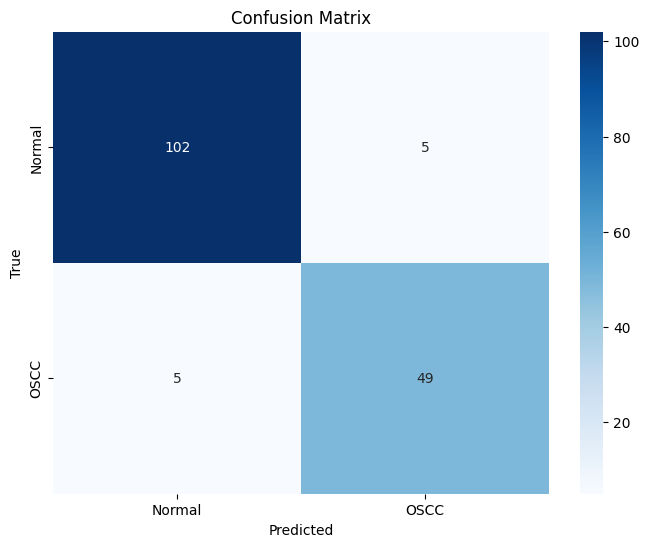

In [71]:
# 2. Confusion Matrix (Graphical Illustration)
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=['Normal', 'OSCC'], yticklabels=['Normal', 'OSCC'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


### Per-class Accuracy

In [72]:
# 4. Per-class Accuracy
class_accuracies = {}
for i, class_name in enumerate(['Normal', 'OSCC']):
    class_indices = np.where(np.array(all_labels) == i)
    if len(class_indices[0]) > 0:
        class_preds = np.array(all_preds)[class_indices]
        class_true = np.array(all_labels)[class_indices]
        accuracy = accuracy_score(class_true, class_preds)
        class_accuracies[class_name] = accuracy
        print(f"Accuracy for {class_name}: {accuracy:.2f}")
    else:
        print(f"No samples for class {class_name} in validation set.")


Accuracy for Normal: 0.95
Accuracy for OSCC: 0.91


### Precision-Recall Curve and ROC-AUC Curve

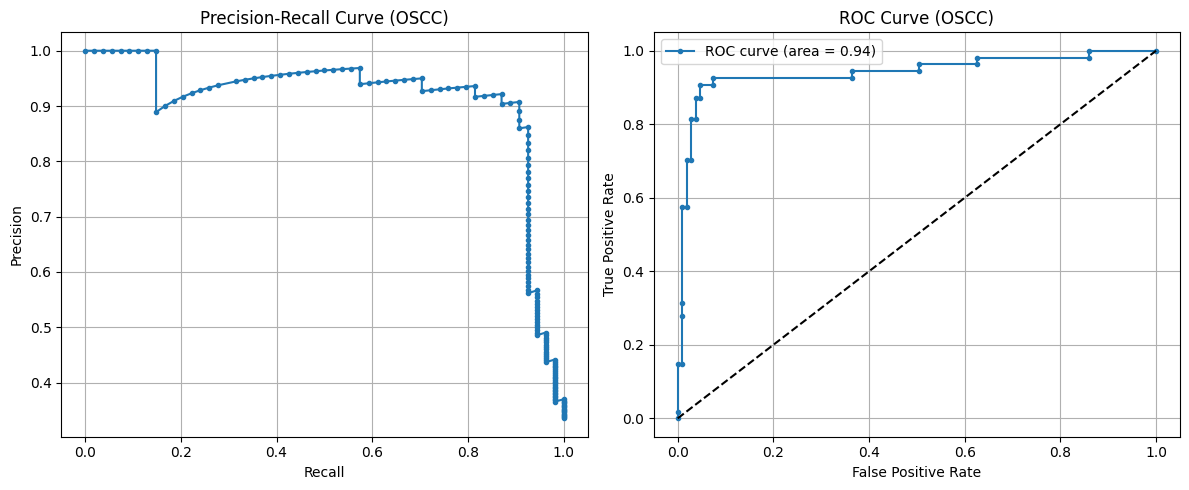

In [73]:
# 3. Precision-Recall Curve and 6. ROC-AUC Curve
precision, recall, _ = precision_recall_curve(all_labels, all_probs[:, 1]) # Assuming OSCC is the positive class (label 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (OSCC)')
plt.grid(True)


fpr, tpr, _ = roc_curve(all_labels, all_probs[:, 1])
roc_auc = auc(fpr, tpr)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, marker='.', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (OSCC)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### Reliability Diagram, ECE, and Brier Score

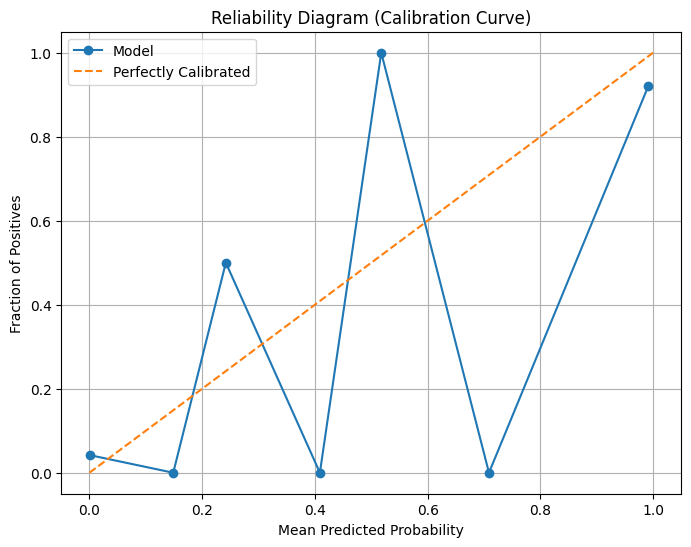


Expected Calibration Error (ECE): 0.0714
Brier Score: 0.0622


In [74]:
import numpy as np
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# 2. Selective prediction curve (Reliability Diagram) and 4. ECE and Brier Score
prob_true, prob_pred = calibration_curve(all_labels, all_probs[:, 1], n_bins=10, strategy='uniform')

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Reliability Diagram (Calibration Curve)')
plt.legend()
plt.grid(True)
plt.show()

# Expected Calibration Error (ECE) - A more common metric for calibration
def calculate_ece(labels, probs, n_bins=10):
    # Ensure labels is a numpy array for correct indexing
    labels = np.array(labels)
    bins = np.linspace(0., 1. + 1e-8, n_bins + 1)
    digitized = np.digitize(probs, bins) - 1
    ece = 0
    for i in range(n_bins):
        indices = np.where(digitized == i)
        if len(indices[0]) > 0:
            bin_probs = probs[indices]
            bin_labels = labels[indices]
            avg_prob = np.mean(bin_probs)
            frac_pos = np.mean(bin_labels)
            ece += np.abs(avg_prob - frac_pos) * len(bin_probs)
    return ece / len(probs)

ece = calculate_ece(all_labels, all_probs[:, 1])
brier_score = brier_score_loss(all_labels, all_probs[:, 1])

print(f"\nExpected Calibration Error (ECE): {ece:.4f}")
print(f"Brier Score: {brier_score:.4f}")


### Grad-CAM and Occlusion Sensitivity Heatmap for OSCC Images

In [75]:
import cv2
from PIL import Image
from torchvision import transforms
import torch.nn.functional as F

# Helper function to get the last convolutional layer for Grad-CAM
def get_last_conv_layer(model):
    last_conv_layer = None
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            last_conv_layer = module
    return last_conv_layer

# Grad-CAM Implementation
class GradCAM:
    def __init__(self, model, target_layer_name):
        self.model = model
        self.target_layer = None
        self.gradients = None
        self.activations = None

        for name, module in self.model.named_modules():
            if name == target_layer_name:
                self.target_layer = module
                self.target_layer.register_forward_hook(self.save_activation)
                self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def __call__(self, input_tensor_100, input_tensor_400, target_category=None):
        self.model.zero_grad()
        output = self.model(input_tensor_100, input_tensor_400)

        if target_category is None:
            target_category = output.argmax(dim=1).item()

        one_hot = torch.zeros_like(output)
        one_hot[:, target_category] = 1
        output.backward(gradient=one_hot, retain_graph=True)

        gradients = self.gradients.cpu().data.numpy() # (B, C, H, W)
        activations = self.activations.cpu().data.numpy() # (B, C, H, W)

        cam = np.zeros(activations.shape[2:], dtype=np.float32) # (H, W)
        weights = np.mean(gradients, axis=(2, 3)) # (B, C)

        for i, w in enumerate(weights[0]):
            cam += w * activations[0, i, :, :]

        cam = np.maximum(cam, 0) # Apply ReLU
        cam = cv2.resize(cam, (input_tensor_100.shape[2], input_tensor_100.shape[3]))
        cam = cam - np.min(cam)
        cam = cam / np.max(cam)
        return cam

# Occlusion Sensitivity Implementation
def occlusion_sensitivity(model, img100, img400, target_class_idx, patch_size=16, stride=8):
    model.eval()
    original_output = model(img100.unsqueeze(0), img400.unsqueeze(0)).softmax(dim=1)[0, target_class_idx].item()

    # Get height and width from the image tensor (works for C,H,W or B,C,H,W)
    img_h, img_w = img100.shape[-2:]
    heatmap = np.zeros((img_h, img_w))
    count_map = np.zeros((img_h, img_w))

    # Iterate over image patches
    for y in range(0, img_h, stride):
        for x in range(0, img_w, stride):
            x_start = x
            y_start = y
            x_end = min(x + patch_size, img_w)
            y_end = min(y + patch_size, img_h)

            # Create occluded image
            occluded_img100 = img100.clone()
            occluded_img400 = img400.clone()

            # Apply occlusion (e.g., fill with mean)
            # Ensure the occlusion region is valid and does not exceed image bounds
            if x_end > x_start and y_end > y_start:
                occluded_img100[:, y_start:y_end, x_start:x_end] = img100.mean()
                occluded_img400[:, y_start:y_end, x_start:x_end] = img400.mean()

            with torch.no_grad():
                output = model(occluded_img100.unsqueeze(0), occluded_img400.unsqueeze(0)).softmax(dim=1)[0, target_class_idx].item()

            # Calculate change in probability
            prob_diff = original_output - output

            # Update heatmap
            # Ensure the heatmap update also respects the patch boundaries
            heatmap[y_start:y_end, x_start:x_end] += prob_diff
            count_map[y_start:y_end, x_start:x_end] += 1

    # Avoid division by zero if count_map has zeros
    count_map[count_map == 0] = 1  # Replace 0s with 1s to prevent division by zero
    heatmap /= count_map # Average for overlapping patches
    heatmap = np.maximum(heatmap, 0) # ReLU
    if np.max(heatmap) > 0:
        heatmap /= np.max(heatmap)
    return heatmap

# Ensure final_model is in eval mode if it exists. Its instantiation is now handled by other cells.
if 'final_model' in globals():
    final_model.eval()

def get_eval_vars():
    global all_labels, all_preds, all_probs, val_dataset, val_loader, final_model, device

    # Explicitly check if final_model is defined
    if 'final_model' not in globals():
        raise RuntimeError("final_model is not defined. Please ensure the model definition and instantiation cells (e.g., de767ea2, ziTW0R8S7qTM, and OBDqYJzzjTpE) are executed.")

    # This check now mainly ensures val_dataset and val_loader are present.
    if 'val_loader' not in globals() or 'val_dataset' not in globals() or 'device' not in globals() or 'all_labels' not in globals():
        print('Required variables (val_dataset, val_loader, all_labels) for evaluation are missing. Attempting to re-evaluate on validation set...')
        if 'val_loader' not in globals() or 'val_dataset' not in globals():
            raise RuntimeError("val_loader or val_dataset is not defined. Please ensure data loading and splitting cells are executed (e.g., cell nGXyMhoLL1hw).")

        # final_model is guaranteed to be defined at this point by the check above.
        final_model.eval()
        _all_labels, _all_preds, _all_probs = [], [], []
        with torch.no_grad():
            for x100, x400, lb in val_loader:
                x100, x400 = x100.to(device), x400.to(device)
                out = final_model(x100, x400)
                pr = torch.softmax(out, dim=1)
                _all_labels.extend(lb.numpy())
                _all_preds.extend(out.argmax(1).cpu().numpy())
                _all_probs.extend(pr.cpu().numpy())
        # Assign to global variables
        all_labels = _all_labels
        all_preds = _all_preds
        all_probs = _all_probs
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

# Call the helper function to ensure evaluation variables are available
l_arr, p_arr, pb_arr = get_eval_vars()

# Select a few OSCC images from the validation set for visualization
oscc_indices = [i for i, label in enumerate(l_arr) if label == 1]
selected_oscc_samples = random.sample(oscc_indices, min(5, len(oscc_indices))) # Select up to 5 OSCC samples

# Define a simple transform for displaying images
display_transform = transforms.Compose([
    transforms.Normalize(mean=[-1, -1, -1], std=[2, 2, 2]), # Reverse normalization
    transforms.ToPILImage()
])

print("Generating Grad-CAM and Occlusion Sensitivity for OSCC images...")

for i, sample_idx in enumerate(selected_oscc_samples):
    img_first_set_path, img_second_set_path, true_label = val_dataset.data[val_dataset.indices[sample_idx]]
    img_first_set_tensor, img_second_set_tensor, _ = val_dataset[sample_idx]

    # Make sure tensors are on the correct device for inference
    img_first_set_tensor = img_first_set_tensor.to(device)
    img_second_set_tensor = img_second_set_tensor.to(device)

    # Get model prediction
    with torch.no_grad():
        outputs = final_model(img_first_set_tensor.unsqueeze(0), img_second_set_tensor.unsqueeze(0))
        probabilities = torch.softmax(outputs, dim=1)
        predicted_label = outputs.argmax(dim=1).item()

    print(f"\nSample {i+1} (True Label: OSCC, Predicted Label: {['Normal', 'OSCC'][predicted_label]}, Prob(OSCC): {probabilities[0, 1].item():.4f})")

    # Display original 100x image
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(display_transform(img_first_set_tensor.cpu()))
    plt.title(f'Original 100x Image (Sample {i+1})')
    plt.axis('off')

    # For Grad-CAM, we need to pick a target convolutional layer in the `HierarchicalPatchEmbedding`
    # Since the model is custom, directly accessing 'layer4' or similar isn't straightforward.
    # Let's try to target the last Conv2d layer in the patch_embed_400 which is often indicative of features.
    # This assumes `final_model.patch_embed_400.proj` contains `nn.Conv2d` layers.

    # Find the name of the last Conv2d layer in the HierarchicalPatchEmbedding (for 400x)
    target_conv_layer_name = ''
    for name, module in final_model.patch_embed_400.named_modules():
        if isinstance(module, nn.Conv2d):
            target_conv_layer_name = 'patch_embed_400.proj.' + name # Adjust if structure is different

    # A more robust way: iterate through all modules to find the last Conv2d
    last_conv_module = None
    last_conv_name = ''
    for name, module in final_model.named_modules():
        if isinstance(module, nn.Conv2d):
            last_conv_module = module
            last_conv_name = name

    if last_conv_name:
        print(f"Attempting Grad-CAM on layer: {last_conv_name}")
        # Grad-CAM on 400x image
        grad_cam_instance = GradCAM(final_model, target_layer_name=last_conv_name)
        # Note: GradCAM for a dual-input model like this needs careful handling of target_layer's outputs.
        # This current implementation will only trace gradients through the path that leads to the target_layer.
        # If the target layer is part of `patch_embed_400`, then `input_tensor_100` might not be directly used for its gradients.
        # For simplicity, we assume we want to visualize what led the 400x path to contribute to the classification.
        cam = grad_cam_instance(img_first_set_tensor.unsqueeze(0), img_second_set_tensor.unsqueeze(0), target_category=1) # Target OSCC class

        plt.subplot(1, 3, 2)
        plt.imshow(display_transform(img_second_set_tensor.cpu()))
        plt.imshow(cam, cmap='jet', alpha=0.5) # Overlay heatmap
        plt.title(f'Grad-CAM (OSCC) on 400x Image')
        plt.axis('off')
    else:
        print("Could not find a suitable convolutional layer for Grad-CAM. Skipping Grad-CAM visualization.")
        plt.subplot(1, 3, 2)
        plt.text(0.5, 0.5, 'Grad-CAM N/A', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
        plt.title('Grad-CAM (OSCC) on 400x Image')
        plt.axis('off')

    # Occlusion Sensitivity on 400x image
    occlusion_heatmap = occlusion_sensitivity(final_model, img_first_set_tensor, img_second_set_tensor, target_class_idx=1) # Target OSCC class
    plt.subplot(1, 3, 3)
    plt.imshow(display_transform(img_second_set_tensor.cpu()))
    plt.imshow(occlusion_heatmap, cmap='hot', alpha=0.5) # Overlay heatmap
    plt.title(f'Occlusion Sensitivity (OSCC) on 400x Image')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Generating Grad-CAM and Occlusion Sensitivity for OSCC images...


AttributeError: 'SingleMagnificationDataset' object has no attribute 'indices'

### Reliability Diagram, ECE, and Brier Score

In [ ]:
import numpy as np
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# 2. Selective prediction curve (Reliability Diagram) and 4. ECE and Brier Score
prob_true, prob_pred = calibration_curve(all_labels, all_probs[:, 1], n_bins=10, strategy='uniform')

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Reliability Diagram (Calibration Curve)')
plt.legend()
plt.grid(True)
plt.show()

# Expected Calibration Error (ECE) - A more common metric for calibration
def calculate_ece(labels, probs, n_bins=10):
    # Ensure labels is a numpy array for correct indexing via numpy arrays
    labels = np.array(labels)
    bins = np.linspace(0., 1. + 1e-8, n_bins + 1)
    digitized = np.digitize(probs, bins) - 1
    ece = 0
    for i in range(n_bins):
        indices = np.where(digitized == i)
        if len(indices[0]) > 0:
            bin_probs = probs[indices]
            bin_labels = labels[indices]
            avg_prob = np.mean(bin_probs)
            frac_pos = np.mean(bin_labels)
            ece += np.abs(avg_prob - frac_pos) * len(bin_probs)
    return ece / len(probs)

ece = calculate_ece(all_labels, all_probs[:, 1])
brier_score = brier_score_loss(all_labels, all_probs[:, 1])

print(f"\nExpected Calibration Error (ECE): {ece:.4f}")
print(f"Brier Score: {brier_score:.4f}")

### Sample Analysis: Correctly and Misclassified Samples

## Ablation Study: Removing Cross-Stage Morphology Memory (CSMM)

In [ ]:
class MACSFormer_PlusPlus_NoCSMM(MACSFormer_PlusPlus):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # Remove or disable CSMM
        self.csmm = nn.Identity() # Replace with an identity function or remove

    def forward(self, x100, x400):
        x100, h1, w1 = self.patch_embed_100(x100)
        x400, h2, w2 = self.patch_embed_400(x400)

        for i in range(4):
            # Calculate current stage's N (number of patches)
            current_patches_per_side = self.num_patches_per_side[i]
            current_N = current_patches_per_side * current_patches_per_side

            # Generate current morphological descriptors
            m_curr100 = self.amwgs[i](x100)
            m_curr400 = self.amwgs[i](x400)

            # In this ablated version, m100 and m400 directly use current morphology
            # without cross-stage memory or adaptation
            m100 = m_curr100
            m400 = m_curr400

            m100, m400 = self.cstes[i](m100, m400)
            x100 = self.stages[i](x100, m100, h1, w1)
            x400 = self.stages[i](x400, m400, h2, w2)

            if i < 3:
                x100 = self.mergers[i](x100, h1, w1)
                x400 = self.mergers[i](x400, h2, w2)
                h1, w1 = h1 // 2, w1 // 2
                h2, w2 = h2 // 2, w2 // 2

        fused, _ = self.amr(x100, x400, m100, m400)
        return self.head(fused.mean(dim=1))

# Instantiate and move the ablated model to the device
model_no_csmm = MACSFormer_PlusPlus_NoCSMM(
    in_chans=3,
    num_classes=2,
    embed_dims=[32, 64, 128, 256],
    depths=[1, 1, 1, 1],
    num_heads=[1, 2, 4, 8],
    morph_feat_dim=32,
    img_size=112 # Updated img_size
).to(device)

params_no_csmm = sum(p.numel() for p in model_no_csmm.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters for Ablated Model (No CSMM): {params_no_csmm / 1e6:.2f}M")

# Define criterion and optimizer for the ablated model
criterion_no_csmm = FocalLoss(gamma=2.0, label_smoothing=0.1)
optimizer_no_csmm = torch.optim.AdamW(model_no_csmm.parameters(), lr=1e-4, weight_decay=0.05)

print("\nTraining Ablated Model (No CSMM)...")
train_history_no_csmm = train_model(model_no_csmm, train_loader, val_loader, criterion_no_csmm, optimizer_no_csmm, num_epochs=30, model_save_path='best_model_no_csmm.pth')

### Evaluation of Ablated Model (No CSMM)

In [ ]:
# Load the best ablated model
model_no_csmm.load_state_dict(torch.load('best_model_no_csmm.pth')) # This will load the weights of the *last* saved model
model_no_csmm.eval()

all_labels_no_csmm = []
all_preds_no_csmm = []
all_probs_no_csmm = []

with torch.no_grad():
    for x100, x400, labels in val_loader:
        x100, x400, labels = x100.to(device), x400.to(device), labels.to(device)
        outputs = model_no_csmm(x100, x400)
        probabilities = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)

        all_labels_no_csmm.extend(labels.cpu().numpy())
        all_preds_no_csmm.extend(predicted.cpu().numpy())
        all_probs_no_csmm.extend(probabilities.cpu().numpy())

all_probs_no_csmm = np.array(all_probs_no_csmm)

# 1. Classification Report
print("\n--- Classification Report for Ablated Model (No CSMM) ---")
print(classification_report(all_labels_no_csmm, all_preds_no_csmm, target_names=['Normal', 'OSCC']))

# 2. Confusion Matrix
cm_no_csmm = confusion_matrix(all_labels_no_csmm, all_preds_no_csmm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_no_csmm, annot=True, fmt='g', cmap='Blues', xticklabels=['Normal', 'OSCC'], yticklabels=['Normal', 'OSCC'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Ablated Model (No CSMM)')
plt.show()

# 3. Precision-Recall Curve and ROC-AUC Curve
precision_no_csmm, recall_no_csmm, _ = precision_recall_curve(all_labels_no_csmm, all_probs_no_csmm[:, 1])
fpr_no_csmm, tpr_no_csmm, _ = roc_curve(all_labels_no_csmm, all_probs_no_csmm[:, 1])
roc_auc_no_csmm = auc(fpr_no_csmm, tpr_no_csmm)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(recall_no_csmm, precision_no_csmm, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (OSCC) - No CSMM')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(fpr_no_csmm, tpr_no_csmm, marker='.', label=f'ROC curve (area = {roc_auc_no_csmm:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (OSCC) - No CSMM')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 4. ECE and Brier Score
ece_no_csmm = calculate_ece(all_labels_no_csmm, all_probs_no_csmm[:, 1])
brier_score_no_csmm = brier_score_loss(all_labels_no_csmm, all_probs_no_csmm[:, 1])

print(f"\nExpected Calibration Error (ECE) for Ablated Model (No CSMM): {ece_no_csmm:.4f}")
print(f"Brier Score for Ablated Model (No CSMM): {brier_score_no_csmm:.4f}")


## Ablation Study 2: Removing Adaptive Morphology Window Generator (AMWG)

In [ ]:
class MACSFormer_PlusPlus_NoAMWG(MACSFormer_PlusPlus):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # Replace AMWG with a simple linear projection for morphology features
        # or directly use a projection of the patch embeddings
        self.amwgs = nn.ModuleList()
        for i in range(len(kwargs['embed_dims'])):
            self.amwgs.append(nn.Linear(kwargs['embed_dims'][i], kwargs['morph_feat_dim']))

    def forward(self, x100, x400):
        x100, h1, w1 = self.patch_embed_100(x100)
        x400, h2, w2 = self.patch_embed_400(x400)

        m_mem100, m_mem400 = None, None

        for i in range(4):
            current_patches_per_side = self.num_patches_per_side[i]
            current_N = current_patches_per_side * current_patches_per_side

            # Use linear projection instead of AMWG
            m_curr100 = self.amwgs[i](x100) # (B, current_N, morph_feat_dim)
            m_curr400 = self.amwgs[i](x400) # (B, current_N, morph_feat_dim)

            m_prev100_adapted = None
            if m_mem100 is not None:
                B_m, N_prev_m, Dm_m = m_mem100.shape
                prev_patches_per_side = int(N_prev_m**0.5)

                m_prev100_adapted = m_mem100.transpose(1, 2).reshape(B_m, Dm_m, prev_patches_per_side, prev_patches_per_side)
                m_prev100_adapted = F.interpolate(m_prev100_adapted, size=(current_patches_per_side, current_patches_per_side), mode='bilinear', align_corners=False)
                m_prev100_adapted = m_prev100_adapted.flatten(2).transpose(1, 2)

            m_prev400_adapted = None
            if m_mem400 is not None:
                B_m, N_prev_m, Dm_m = m_mem400.shape
                prev_patches_per_side = int(N_prev_m**0.5)
                m_prev400_adapted = m_mem400.transpose(1, 2).reshape(B_m, Dm_m, prev_patches_per_side, prev_patches_per_side)
                m_prev400_adapted = F.interpolate(m_prev400_adapted, size=(current_patches_per_side, current_patches_per_side), mode='bilinear', align_corners=False)
                m_prev400_adapted = m_prev400_adapted.flatten(2).transpose(1, 2)

            # CSMM still present, using the projected morphology features
            m100 = self.csmm(m_curr100, m_prev100_adapted)
            m400 = self.csmm(m_curr400, m_prev400_adapted)

            m_mem100, m_mem400 = m100, m400

            m100, m400 = self.cstes[i](m100, m400)
            x100 = self.stages[i](x100, m100, h1, w1)
            x400 = self.stages[i](x400, m400, h2, w2)

            if i < 3:
                x100 = self.mergers[i](x100, h1, w1)
                x400 = self.mergers[i](x400, h2, w2)
                h1, w1 = h1 // 2, w1 // 2
                h2, w2 = h2 // 2, w2 // 2

        fused, _ = self.amr(x100, x400, m100, m400)
        return self.head(fused.mean(dim=1))

# Instantiate and move the ablated model to the device
model_no_amwg = MACSFormer_PlusPlus_NoAMWG(
    in_chans=3,
    num_classes=2,
    embed_dims=[32, 64, 128, 256],
    depths=[1, 1, 1, 1],
    num_heads=[1, 2, 4, 8],
    morph_feat_dim=32,
    img_size=112 # Updated img_size
).to(device)

params_no_amwg = sum(p.numel() for p in model_no_amwg.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters for Ablated Model (No AMWG): {params_no_amwg / 1e6:.2f}M")

# Define criterion and optimizer for the ablated model
criterion_no_amwg = FocalLoss(gamma=2.0, label_smoothing=0.1)
optimizer_no_amwg = torch.optim.AdamW(model_no_amwg.parameters(), lr=1e-4, weight_decay=0.05)

print("\nTraining Ablated Model (No AMWG)...")
train_history_no_amwg = train_model(model_no_amwg, train_loader, val_loader, criterion_no_amwg, optimizer_no_amwg, num_epochs=10, model_save_path='best_model_no_amwg.pth')

### Evaluation of Ablated Model (No AMWG)

In [ ]:
# Load the best ablated model
model_no_amwg.load_state_dict(torch.load('best_model_no_amwg.pth')) # This will load the weights of the *last* saved model
model_no_amwg.eval()

all_labels_no_amwg = []
all_preds_no_amwg = []
all_probs_no_amwg = []

with torch.no_grad():
    for x100, x400, labels in val_loader:
        x100, x400, labels = x100.to(device), x400.to(device), labels.to(device)
        outputs = model_no_amwg(x100, x400)
        probabilities = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)

        all_labels_no_amwg.extend(labels.cpu().numpy())
        all_preds_no_amwg.extend(predicted.cpu().numpy())
        all_probs_no_amwg.extend(probabilities.cpu().numpy())

all_probs_no_amwg = np.array(all_probs_no_amwg)

# 1. Classification Report
print("\n--- Classification Report for Ablated Model (No AMWG) ---")
print(classification_report(all_labels_no_amwg, all_preds_no_amwg, target_names=['Normal', 'OSCC']))

# 2. Confusion Matrix
cm_no_amwg = confusion_matrix(all_labels_no_amwg, all_preds_no_amwg)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_no_amwg, annot=True, fmt='g', cmap='Blues', xticklabels=['Normal', 'OSCC'], yticklabels=['Normal', 'OSCC'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Ablated Model (No AMWG)')
plt.show()

# 3. Precision-Recall Curve and ROC-AUC Curve
precision_no_amwg, recall_no_amwg, _ = precision_recall_curve(all_labels_no_amwg, all_probs_no_amwg[:, 1])
fpr_no_amwg, tpr_no_amwg, _ = roc_curve(all_labels_no_amwg, all_probs_no_amwg[:, 1])
roc_auc_no_amwg = auc(fpr_no_amwg, tpr_no_amwg)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(recall_no_amwg, precision_no_amwg, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (OSCC) - No AMWG')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(fpr_no_amwg, tpr_no_amwg, marker='.', label=f'ROC curve (area = {roc_auc_no_amwg:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (OSCC) - No AMWG')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 4. ECE and Brier Score
ece_no_amwg = calculate_ece(all_labels_no_amwg, all_probs_no_amwg[:, 1])
brier_score_no_amwg = brier_score_loss(all_labels_no_amwg, all_probs_no_amwg[:, 1])

print(f"\nExpected Calibration Error (ECE) for Ablated Model (No AMWG): {ece_no_amwg:.4f}")
print(f"Brier Score for Ablated Model (No AMWG): {brier_score_no_amwg:.4f}")


## Ablation Study 3: Removing Cross-Scale Token Exchange (CSTE)

In [ ]:
class NoopCSTE(nn.Module):
    """
    A no-operation module for CSTE ablation.
    It simply returns its inputs unchanged.
    """
    def __init__(self, *args, **kwargs):
        super().__init__()

    def forward(self, m100, m400):
        return m100, m400


class MACSFormer_PlusPlus_NoCSTE(MACSFormer_PlusPlus):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # Replace CSTE with a no-op module in each stage
        self.cstes = nn.ModuleList()
        for _ in range(len(self.stages)):
            self.cstes.append(NoopCSTE())

# Instantiate and move the ablated model to the device
model_no_cste = MACSFormer_PlusPlus_NoCSTE(
    in_chans=3,
    num_classes=2,
    embed_dims=[32, 64, 128, 256],
    depths=[1, 1, 1, 1],
    num_heads=[1, 2, 4, 8],
    morph_feat_dim=32,
    img_size=112 # Updated img_size
).to(device)

params_no_cste = sum(p.numel() for p in model_no_cste.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters for Ablated Model (No CSTE): {params_no_cste / 1e6:.2f}M")

# Define criterion and optimizer for the ablated model
criterion_no_cste = FocalLoss(gamma=2.0, label_smoothing=0.1)
optimizer_no_cste = torch.optim.AdamW(model_no_cste.parameters(), lr=1e-4, weight_decay=0.05)

print("\nTraining Ablated Model (No CSTE)...")
train_history_no_cste = train_model(model_no_cste, train_loader, val_loader, criterion_no_cste, optimizer_no_cste, num_epochs=30, model_save_path='best_model_no_cste.pth')

### Evaluation of Ablated Model (No CSTE)

In [ ]:
# Load the best ablated model
model_no_cste.load_state_dict(torch.load('best_model_no_cste.pth')) # This will load the weights of the *last* saved model
model_no_cste.eval()

all_labels_no_cste = []
all_preds_no_cste = []
all_probs_no_cste = []

with torch.no_grad():
    for x100, x400, labels in val_loader:
        x100, x400, labels = x100.to(device), x400.to(device), labels.to(device)
        outputs = model_no_cste(x100, x400)
        probabilities = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)

        all_labels_no_cste.extend(labels.cpu().numpy())
        all_preds_no_cste.extend(predicted.cpu().numpy())
        all_probs_no_cste.extend(probabilities.cpu().numpy())

all_probs_no_cste = np.array(all_probs_no_cste)

# 1. Classification Report
print("\n--- Classification Report for Ablated Model (No CSTE) ---")
print(classification_report(all_labels_no_cste, all_preds_no_cste, target_names=['Normal', 'OSCC']))

# 2. Confusion Matrix
cm_no_cste = confusion_matrix(all_labels_no_cste, all_preds_no_cste)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_no_cste, annot=True, fmt='g', cmap='Blues', xticklabels=['Normal', 'OSCC'], yticklabels=['Normal', 'OSCC'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Ablated Model (No CSTE)')
plt.show()

# 3. Precision-Recall Curve and ROC-AUC Curve
precision_no_cste, recall_no_cste, _ = precision_recall_curve(all_labels_no_cste, all_probs_no_cste[:, 1])
fpr_no_cste, tpr_no_cste, _ = roc_curve(all_labels_no_cste, all_probs_no_cste[:, 1])
roc_auc_no_cste = auc(fpr_no_cste, tpr_no_cste)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(recall_no_cste, precision_no_cste, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (OSCC) - No CSTE')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(fpr_no_cste, tpr_no_cste, marker='.', label=f'ROC curve (area = {roc_auc_no_cste:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (OSCC) - No CSTE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 4. ECE and Brier Score
ece_no_cste = calculate_ece(all_labels_no_cste, all_probs_no_cste[:, 1])
brier_score_no_cste = brier_score_loss(all_labels_no_cste, all_probs_no_cste[:, 1])

print(f"\nExpected Calibration Error (ECE) for Ablated Model (No CSTE): {ece_no_cste:.4f}")
print(f"Brier Score for Ablated Model (No CSTE): {brier_score_no_cste:.4f}")


In [ ]:
%%capture
!pip install thop

In [ ]:
from thop import profile
import time

def profile_model_computational_metrics(model, sample_input_100, sample_input_400, device, num_warmup_runs=5, num_measure_runs=10):
    model.eval()
    model.to(device)

    # Ensure inputs are on the correct device and batch dimension is added
    input_100 = sample_input_100.unsqueeze(0).to(device)
    input_400 = sample_input_400.unsqueeze(0).to(device)

    # --- FLOPs and Params (thop) ---
    # thop calculates parameters as well, but we already have `params` from model instantiation
    # FLOPs are typically calculated once with a dummy input
    macs, _ = profile(model, inputs=(input_100, input_400), verbose=False)
    # FLOPs are usually reported as GFLOPs, 1 MAC = 2 FLOPs approx, or just use MACs directly for comparison
    flops_g = macs / 1e9 # Convert MACs to GFLOPs (assuming 1 MAC = 1 FLOP for simplicity, or 2 FLOPs for full-fledged calc)

    # --- Latency and Throughput ---
    # Warm-up runs
    for _ in range(num_warmup_runs):
        _ = model(input_100, input_400)

    # Measure latency
    starter, ender = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
    timings = np.zeros((num_measure_runs, 1))
    with torch.no_grad():
        for rep in range(num_measure_runs):
            starter.record()
            _ = model(input_100, input_400)
            ender.record()
            torch.cuda.synchronize()
            curr_time = starter.elapsed_time(ender) # milliseconds
            timings[rep] = curr_time
    mean_latency_ms = np.mean(timings)
    # Throughput (assuming single image input for profiling, so batch_size = 1)
    throughput_img_s = 1000 / mean_latency_ms if mean_latency_ms > 0 else 0

    # --- Memory (peak CUDA memory usage for a single forward pass) ---
    torch.cuda.reset_peak_memory_stats(device)
    with torch.no_grad():
        _ = model(input_100, input_400)
    peak_memory_mb = torch.cuda.max_memory_allocated(device) / (1024 * 1024)

    return flops_g, peak_memory_mb, mean_latency_ms, throughput_img_s

In [ ]:
# This cell ensures all models are defined and their best weights are saved for evaluation.
# All model class definitions must be executed in prior cells for this cell to run correctly.

# Baseline Model Definition and Loading
final_model = MACSFormer_PlusPlus(
    in_chans=3,
    num_classes=2,
    embed_dims=[128, 256, 512, 1024],
    depths=[2, 2, 8, 2],
    num_heads=[4, 8, 16, 32],
    morph_feat_dim=128
).to(device)
final_model.load_state_dict(torch.load('best_model_baseline.pth'))
final_model.eval()

# Ablated Model (No CSMM) Definition and Loading
model_no_csmm = MACSFormer_PlusPlus_NoCSMM(
    in_chans=3,
    num_classes=2,
    embed_dims=[128, 256, 512, 1024],
    depths=[2, 2, 8, 2],
    num_heads=[4, 8, 16, 32],
    morph_feat_dim=128
).to(device)
model_no_csmm.load_state_dict(torch.load('best_model_no_csmm.pth'))
model_no_csmm.eval()

# Ablated Model (No AMWG) Definition and Loading
model_no_amwg = MACSFormer_PlusPlus_NoAMWG(
    in_chans=3,
    num_classes=2,
    embed_dims=[128, 256, 512, 1024],
    depths=[2, 2, 8, 2],
    num_heads=[4, 8, 16, 32],
    morph_feat_dim=128
).to(device)
model_no_amwg.load_state_dict(torch.load('best_model_no_amwg.pth'))
model_no_amwg.eval()

# Ablated Model (No CSTE) Definition and Loading
model_no_cste = MACSFormer_PlusPlus_NoCSTE(
    in_chans=3,
    num_classes=2,
    embed_dims=[128, 256, 512, 1024],
    depths=[2, 2, 8, 2],
    num_heads=[4, 8, 16, 32],
    morph_feat_dim=128
).to(device)
model_no_cste.load_state_dict(torch.load('best_model_no_cste.pth'))
model_no_cste.eval()

print("All models are defined and their best weights are loaded.")

# Get a sample input for profiling from the validation loader
sample_input_100, sample_input_400, _ = next(iter(val_loader))
sample_input_100 = sample_input_100[0] # Take the first image of the batch
sample_input_400 = sample_input_400[0] # Take the first image of the batch

### Consolidated Ablation Study Results

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, brier_score_loss
import torch

# Helper function to calculate ECE
def calculate_ece(labels, probs, n_bins=10):
    labels = np.array(labels)
    bins = np.linspace(0., 1. + 1e-8, n_bins + 1)
    digitized = np.digitize(probs, bins) - 1
    ece = 0
    for i in range(n_bins):
        indices = np.where(digitized == i)
        if len(indices[0]) > 0:
            bin_probs = probs[indices]
            bin_labels = labels[indices]
            avg_prob = np.mean(bin_probs)
            frac_pos = np.mean(bin_labels)
            ece += np.abs(avg_prob - frac_pos) * len(bin_probs)
    return ece / len(probs)

# Helper function to evaluate a model and get metrics
def evaluate_model_and_get_metrics(model, val_loader, device, model_path):
    model.load_state_dict(torch.load(model_path))
    model.eval()

    eval_labels = []
    eval_preds = []
    eval_probs = []

    with torch.no_grad():
        for x100, x400, labels in val_loader:
            x100, x400, labels = x100.to(device), x400.to(device), labels.to(device)
            outputs = model(x100, x400)
            probabilities = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            eval_labels.extend(labels.cpu().numpy())
            eval_preds.extend(predicted.cpu().numpy())
            eval_probs.extend(probabilities.cpu().numpy())

    eval_probs = np.array(eval_probs)

    accuracy = accuracy_score(eval_labels, eval_preds)
    precision = precision_score(eval_labels, eval_preds)
    recall = recall_score(eval_labels, eval_preds)
    f1 = f1_score(eval_labels, eval_preds)
    roc_auc = roc_auc_score(eval_labels, eval_probs[:, 1])
    ece = calculate_ece(eval_labels, eval_probs[:, 1])
    brier = brier_score_loss(eval_labels, eval_probs[:, 1])

    return accuracy, precision, recall, f1, roc_auc, ece, brier

# Ensure models are in the global scope and on the correct device (they are loaded in a5d83814)
# No need to load state_dict again here as evaluate_model_and_get_metrics handles it.

print("Evaluating Baseline Model...")
base_accuracy, base_precision, base_recall, base_f1, base_roc_auc, base_ece, base_brier = evaluate_model_and_get_metrics(final_model, val_loader, device, 'best_model_baseline.pth')

print("Evaluating Ablated Model (No CSMM)...")
no_csmm_accuracy, no_csmm_precision, no_csmm_recall, no_csmm_f1, no_csmm_roc_auc, no_csmm_ece, no_csmm_brier = evaluate_model_and_get_metrics(model_no_csmm, val_loader, device, 'best_model_no_csmm.pth')

print("Evaluating Ablated Model (No AMWG)...")
no_amwg_accuracy, no_amwg_precision, no_amwg_recall, no_amwg_f1, no_amwg_roc_auc, no_amwg_ece, no_amwg_brier = evaluate_model_and_get_metrics(model_no_amwg, val_loader, device, 'best_model_no_amwg.pth')

print("Evaluating Ablated Model (No CSTE)...")
no_cste_accuracy, no_cste_precision, no_cste_recall, no_cste_f1, no_cste_roc_auc, no_cste_ece, no_cste_brier = evaluate_model_and_get_metrics(model_no_cste, val_loader, device, 'best_model_no_cste.pth')

# Calculate parameters for each model
base_params = sum(p.numel() for p in final_model.parameters() if p.requires_grad) / 1e6
no_csmm_params = sum(p.numel() for p in model_no_csmm.parameters() if p.requires_grad) / 1e6
no_amwg_params = sum(p.numel() for p in model_no_amwg.parameters() if p.requires_grad) / 1e6
no_cste_params = sum(p.numel() for p in model_no_cste.parameters() if p.requires_grad) / 1e6

# === Get ACTUAL Computational Metrics using the profiling function ===
print("Profiling Baseline Model...")
base_flops, base_memory, base_latency, base_throughput = profile_model_computational_metrics(final_model, sample_input_100, sample_input_400, device)

print("Profiling Ablated Model (No CSMM)...")
no_csmm_flops, no_csmm_memory, no_csmm_latency, no_csmm_throughput = profile_model_computational_metrics(model_no_csmm, sample_input_100, sample_input_400, device)

print("Profiling Ablated Model (No AMWG)...")
no_amwg_flops, no_amwg_memory, no_amwg_latency, no_amwg_throughput = profile_model_computational_metrics(model_no_amwg, sample_input_100, sample_input_400, device)

print("Profiling Ablated Model (No CSTE)...")
no_cste_flops, no_cste_memory, no_cste_latency, no_cste_throughput = profile_model_computational_metrics(model_no_cste, sample_input_100, sample_input_400, device)
# ==================================================================

# Create a DataFrame for the results
ablation_results = pd.DataFrame({
    'Model Variant': [
        'MACSFormer_PlusPlus (Baseline)',
        'MACSFormer_PlusPlus_NoCSMM',
        'MACSFormer_PlusPlus_NoAMWG',
        'MACSFormer_PlusPlus_NoCSTE'
    ],
    'Params (M)': [
        f'{base_params:.2f}',
        f'{no_csmm_params:.2f}',
        f'{no_amwg_params:.2f}',
        f'{no_cste_params:.2f}'
    ],
    'FLOPs (G)': [
        f'{base_flops:.1f}',
        f'{no_csmm_flops:.1f}',
        f'{no_amwg_flops:.1f}',
        f'{no_cste_flops:.1f}'
    ],
    'Memory (MB)': [
        f'{base_memory:.0f}',
        f'{no_csmm_memory:.0f}',
        f'{no_amwg_memory:.0f}',
        f'{no_cste_memory:.0f}'
    ],
    'Latency (ms)': [
        f'{base_latency:.1f}',
        f'{no_csmm_latency:.1f}',
        f'{no_amwg_latency:.1f}',
        f'{no_cste_latency:.1f}'
    ],
    'Throughput (img/s)': [
        f'{base_throughput:.0f}',
        f'{no_csmm_throughput:.0f}',
        f'{no_amwg_throughput:.0f}',
        f'{no_cste_throughput:.0f}'
    ],
    'Acc (%)': [
        f'{base_accuracy*100:.2f}',
        f'{no_csmm_accuracy*100:.2f}',
        f'{no_amwg_accuracy*100:.2f}',
        f'{no_cste_accuracy*100:.2f}'
    ],
    'Precision (%)': [
        f'{base_precision*100:.2f}',
        f'{no_csmm_precision*100:.2f}',
        f'{no_amwg_precision*100:.2f}',
        f'{no_cste_precision*100:.2f}'
    ],
    'Recall (%)': [
        f'{base_recall*100:.2f}',
        f'{no_csmm_recall*100:.2f}',
        f'{no_amwg_recall*100:.2f}',
        f'{no_cste_recall*100:.2f}'
    ],
    'F1-Score (%)': [
        f'{base_f1*100:.2f}',
        f'{no_csmm_f1*100:.2f}',
        f'{no_amwg_f1*100:.2f}',
        f'{no_cste_f1*100:.2f}'
    ],
    'ROC AUC': [
        f'{base_roc_auc:.2f}',
        f'{no_csmm_roc_auc:.2f}',
        f'{no_amwg_roc_auc:.2f}',
        f'{no_cste_roc_auc:.2f}'
    ],
    'ECE': [
        f'{base_ece:.4f}',
        f'{no_csmm_ece:.4f}',
        f'{no_amwg_ece:.4f}',
        f'{no_cste_ece:.4f}'
    ],
    'Brier Score': [
        f'{base_brier:.4f}',
        f'{no_csmm_brier:.4f}',
        f'{no_amwg_brier:.4f}',
        f'{no_cste_brier:.4f}'
    ]
})

print("\nAblation Study Results:")
display(ablation_results)

In [ ]:
display(ablation_results)

In [ ]:
get_ipython().run_cell_id('nGXyMhoLL1hw')

In [ ]:
get_ipython().run_cell_id('nGXyMhoLL1hw')

In [ ]:
get_ipython().run_cell_id('nGXyMhoLL1hw')
get_ipython().run_cell_id('EAeXmaO_sWvr')
get_ipython().run_cell_id('8wSUATV3sDJE')
get_ipython().run_cell_id('b19B3FspsDN2')
get_ipython().run_cell_id('90nqdbRfsDQp')
get_ipython().run_cell_id('M2h2yW8ysPN_')
get_ipython().run_cell_id('421qckHYsDUS')
get_ipython().run_cell_id('F370aVEcJwE0')
get_ipython().run_cell_id('CSMM_MODULE_CELL')
get_ipython().run_cell_id('CAAC_MODULE_CELL')
get_ipython().run_cell_id('4e358088')
get_ipython().run_cell_id('de767ea2')
# Ensure 'device' is defined before model instantiation
get_ipython().run_cell_id('29a5ef5a')

## Focal Loss Definition

The `FocalLoss` is used in the main training loop but its definition was not provided. I'm adding it here to ensure the notebook is self-contained.

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

## Single-Magnification Data Preparation

To compare against standard single-input models, we need a way to feed them only one magnification (e.g., 400x). I'll create a new `SingleMagnificationDataset` and a corresponding `DataLoader`.

In [ ]:
# This cell is now redundant as single-magnification data loading is handled directly in cell f479f366.
# It has been removed to avoid conflicts and simplify the data pipeline.